In [35]:
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import numpy as np
import h5flow

In [36]:
# DUNE plot style
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [37]:
# ── Configuration ──────────────────────────────────────────────────────────────
PERIODS = [32, 80, 109, 128, 147, 176, 195, 224, 272, 291, 320]

CLUSTER_BASE = "/global/cfs/cdirs/dune/users/lmlepin/cluster_outputs/"
TEXT_FILE_BASE = "/global/cfs/cdirs/dune/users/lmlepin/neutron_samples/"
CACHE_DIR = "cl_matching_cache/"

MIN_CHARGE_HITS = 0        # extract everything, filter at plot time
FORCE_REPROCESS = False    # set True to re-extract even if cache exists
MAX_FILES = None           # limit files per period for testing (None = all)
SECONDS_PER_FILE = 90

# ── Plot-time charge hit thresholds ───────────────────────────────────────────
CHARGE_HIT_CUTS = [0, 3]   # generate figures for each of these thresholds

# ── Figure output ─────────────────────────────────────────────────────────────
FIGURE_DIR = "figures/"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [38]:
# ── Helper functions ───────────────────────────────────────────────────────────

def build_file_id_map(text_file_path):
    """Read a text file listing HDF5 paths and return {file_id: full_path}."""
    with open(text_file_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    return {i: path for i, path in enumerate(lines)}


def find_cluster_csvs(period):
    """Find the prompt and delayed aggregated cluster CSVs for a given period.
    Returns list of dicts with keys: 'prompt_csv', 'delayed_csv', 'text_file', 'label'.
    Multiple entries for periods with set_B.
    """
    results = []

    # Main directory
    pattern = f"{CLUSTER_BASE}AmBe_mod2_pmt_trigger_{period}us_period_[0-9]*/"
    dirs = sorted(glob.glob(pattern))
    if dirs:
        d = dirs[0]
        prompt = glob.glob(os.path.join(d, "*_clusters_prompt.csv"))
        delayed = glob.glob(os.path.join(d, "*_clusters_delayed.csv"))
        text_file = f"{TEXT_FILE_BASE}AmBe_mod2_pmt_trigger_{period}us_period.txt"
        results.append({
            "prompt_csv": prompt[0] if prompt else None,
            "delayed_csv": delayed[0] if delayed else None,
            "text_file": text_file,
            "label": f"{period}us",
        })

    # set_B directory (80us and 320us)
    pattern_b = f"{CLUSTER_BASE}AmBe_mod2_pmt_trigger_{period}us_period_set_B_*/"
    dirs_b = sorted(glob.glob(pattern_b))
    if dirs_b:
        d = dirs_b[0]
        prompt = glob.glob(os.path.join(d, "*_clusters_prompt.csv"))
        delayed = glob.glob(os.path.join(d, "*_clusters_delayed.csv"))
        text_file = f"{TEXT_FILE_BASE}AmBe_mod2_pmt_trigger_{period}us_period_set_B.txt"
        results.append({
            "prompt_csv": prompt[0] if prompt else None,
            "delayed_csv": delayed[0] if delayed else None,
            "text_file": text_file,
            "label": f"{period}us_set_B",
        })

    return results


# Quick sanity check
for p in PERIODS:
    csvs = find_cluster_csvs(p)
    for entry in csvs:
        ok_p = "OK" if entry["prompt_csv"] else "MISSING"
        ok_d = "OK" if entry["delayed_csv"] else "MISSING"
        ok_t = "OK" if os.path.exists(entry["text_file"]) else "MISSING"
        print(f"  {entry['label']:>15s}  prompt={ok_p}  delayed={ok_d}  text={ok_t}")

             32us  prompt=OK  delayed=OK  text=OK
             80us  prompt=MISSING  delayed=MISSING  text=OK
       80us_set_B  prompt=OK  delayed=OK  text=OK
            109us  prompt=OK  delayed=OK  text=OK
            128us  prompt=OK  delayed=OK  text=OK
            147us  prompt=OK  delayed=OK  text=OK
            176us  prompt=OK  delayed=OK  text=OK
            195us  prompt=OK  delayed=OK  text=OK
            224us  prompt=OK  delayed=OK  text=OK
            272us  prompt=OK  delayed=OK  text=OK
            291us  prompt=OK  delayed=OK  text=OK
            320us  prompt=OK  delayed=OK  text=OK
      320us_set_B  prompt=OK  delayed=OK  text=OK


In [39]:
# ── TRAP_NAME_MAP ─────────────────────────────────────────────────────────────
TRAP_NAME_MAP = [
    # ----- ADC 0 (ACLs module 0) -----
    dict(adc=0, channels=[4,5,6,7,8,9],   name="ACL 2.01", tpc=0, z_side="-z", position="bottom"),
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0, z_side="-z", position="top"),
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0, z_side="+z", position="bottom"),
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0, z_side="+z", position="top"),
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1, z_side="-z", position="bottom"),
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1, z_side="-z", position="top"),
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1, z_side="+z", position="bottom"),
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1, z_side="+z", position="top"),
    # ----- ADC 1 (LCMs module 0) -----
    dict(adc=1, channels=[4,5,6,7,8,9],   name="LCM 100,101,102", tpc=0, z_side="-z", position="bottom"),
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103,104,105", tpc=0, z_side="-z", position="top"),
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106,107,108", tpc=0, z_side="+z", position="bottom"),
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109,110,111", tpc=0, z_side="+z", position="top"),
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112,113,114", tpc=1, z_side="-z", position="bottom"),
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115,116,117", tpc=1, z_side="-z", position="top"),
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118,119,120", tpc=1, z_side="+z", position="bottom"),
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121,122,123", tpc=1, z_side="+z", position="top"),
    # ----- ADC 2 (ACLs module 1) -----
    dict(adc=2, channels=[4,5,6,7,8,9],   name="ACL 2.09", tpc=2, z_side="-z", position="bottom"),
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2, z_side="-z", position="top"),
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2, z_side="+z", position="bottom"),
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2, z_side="+z", position="top"),
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3, z_side="-z", position="bottom"),
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3, z_side="-z", position="top"),
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3, z_side="+z", position="bottom"),
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3, z_side="+z", position="top"),
    # ----- ADC 3 (LCMs module 1) -----
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124,125,126", tpc=2, z_side="-z", position="bottom"),
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127,128,129", tpc=2, z_side="-z", position="top"),
    dict(adc=3, channels=[4,5,6,7,8,9],   name="LCM 130,131,132", tpc=2, z_side="+z", position="bottom"),
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133,134,135", tpc=2, z_side="+z", position="top"),
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136,137,138", tpc=3, z_side="-z", position="bottom"),
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139,140,141", tpc=3, z_side="-z", position="top"),
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142,143,144", tpc=3, z_side="+z", position="bottom"),
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145,146,147", tpc=3, z_side="+z", position="top"),
    # ----- ADC 4 (mix module 2) -----
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17",       tpc=4, z_side="-z", position="bottom"),
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18",       tpc=4, z_side="-z", position="top"),
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148,149,150",tpc=4, z_side="+z", position="bottom"),
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151,152,153",tpc=4, z_side="+z", position="top"),
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19",       tpc=5, z_side="-z", position="bottom"),
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20",       tpc=5, z_side="-z", position="top"),
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21",       tpc=5, z_side="+z", position="bottom"),
    dict(adc=4, channels=[4,5,6,7,8,9],   name="ACL 2.22",           tpc=5, z_side="+z", position="top"),
    # ----- ADC 5 (mix module 2) -----
    dict(adc=5, channels=[42,43,44,45,46,47], name="LCM 154,155,156",tpc=4, z_side="-z", position="bottom"),
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23",       tpc=4, z_side="+z", position="bottom"),
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24",       tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157,158,159",tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160,161,162",tpc=5, z_side="-z", position="bottom"),
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163,164,165",tpc=5, z_side="-z", position="top"),
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166,167,168",tpc=5, z_side="+z", position="bottom"),
    dict(adc=5, channels=[4,5,6,7,8,9],   name="LCM 169,170,171",    tpc=5, z_side="+z", position="top"),
    # ----- ADC 6 (ACLs module 3) -----
    dict(adc=6, channels=[4,5,6,7,8,9],   name="ACL 2.25", tpc=6, z_side="-z", position="bottom"),
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6, z_side="-z", position="top"),
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6, z_side="+z", position="bottom"),
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6, z_side="+z", position="top"),
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7, z_side="-z", position="bottom"),
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7, z_side="-z", position="top"),
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7, z_side="+z", position="bottom"),
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7, z_side="+z", position="top"),
    # ----- ADC 7 (LCMs module 3) -----
    dict(adc=7, channels=[4,5,6,7,8,9],   name="LCM 172,173,174", tpc=6, z_side="-z", position="bottom"),
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175,176,177", tpc=6, z_side="-z", position="top"),
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178,179,180", tpc=6, z_side="+z", position="bottom"),
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181,182,183", tpc=6, z_side="+z", position="top"),
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184,185,186", tpc=7, z_side="-z", position="bottom"),
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187,188,189", tpc=7, z_side="-z", position="top"),
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190,191,192", tpc=7, z_side="+z", position="bottom"),
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193,194,195", tpc=7, z_side="+z", position="top"),
]

# Build trap lookup DataFrame
tpc_counts = {}
rows = []
for entry in TRAP_NAME_MAP:
    tpc = entry["tpc"]
    det = tpc_counts.get(tpc, 0)
    tpc_counts[tpc] = det + 1
    rows.append({
        "tpc":       tpc,
        "det":       det,
        "trap_name": entry["name"],
        "trap_type": "ACL" if entry["name"].startswith("ACL") else "LCM",
        "position":  entry["position"],
        "z_side":    entry["z_side"],
        "adc":       entry["adc"],
    })
trap_lookup = pd.DataFrame(rows)

In [40]:
# ── extract_events() ──────────────────────────────────────────────────────────

def extract_events(csv_df, file_ids_map, period, window,
                   min_charge_hits=MIN_CHARGE_HITS, max_files=None):
    """
    For each valid (file_id, light_id) in csv_df, open the corresponding HDF5
    file and extract light quantities.  Returns a DataFrame with one row per event.

    file_ids_map values must be full absolute paths to HDF5 files.
    """
    file_ids_in_csv = sorted(csv_df["file_id"].dropna().unique().astype(int))
    if max_files is not None:
        file_ids_in_csv = file_ids_in_csv[:max_files]

    records = []
    for file_id in file_ids_in_csv:
        if file_id not in file_ids_map:
            print(f"  Warning: file_id {file_id} not in text file, skipping")
            continue

        matching = csv_df[(csv_df["cluster_label"] != -1) & (csv_df["file_id"] == file_id)]
        valid_groups = matching.groupby("light_id").filter(lambda x: len(x) > min_charge_hits)
        if len(valid_groups) == 0:
            continue

        hdf5_path = file_ids_map[file_id]
        data = h5flow.data.H5FlowDataManager(hdf5_path, "r")
        try:
            for light_id, group in valid_groups.groupby("light_id"):
                try:
                    sum_hits = data['/light/events/', 'light/sum_hits'][int(light_id)]
                except IndexError:
                    continue
                fprompt  = np.ma.filled(sum_hits["fprompt"],  np.nan)
                integral = np.ma.filled(sum_hits["integral"], np.nan)
                tpc      = np.ma.filled(sum_hits["tpc"].astype(int), -1)
                det      = np.ma.filled(sum_hits["det"].astype(int), -1)

                valid_mask = ~np.isnan(fprompt)

                if valid_mask.sum() > 0:
                    best_idx       = np.nanargmax(integral)
                    fprompt_best   = float(fprompt[best_idx])
                    integral_best  = float(integral[best_idx])
                    tpc_best       = int(tpc[best_idx])
                    det_best       = int(det[best_idx])
                else:
                    fprompt_best  = np.nan
                    integral_best = np.nan
                    tpc_best      = -1
                    det_best      = -1

                records.append({
                    "file_id":         file_id,
                    "light_id":        int(light_id),
                    "n_charge_hits":   len(group),
                    "charge_x":        group["x"].mean(),
                    "charge_y":        group["y"].mean(),
                    "charge_z":        group["z"].mean(),
                    "charge_E":        group["E"].sum(),
                    "charge_Q":        group["Q"].sum(),
                    "fprompt":         fprompt_best,
                    "integral":        integral_best,
                    "integral_total":  float(np.nansum(integral[valid_mask])),
                    "tpc":             tpc_best,
                    "det":             det_best,
                    "n_valid_sumhits": int(valid_mask.sum()),
                    "period":          period,
                    "window":          window,
                })
        finally:
            data.finish()

    return pd.DataFrame(records)

## Processing loop

In [41]:
# ── Process all periods (with CSV caching) ────────────────────────────────────
all_events = []
_cache_tag = f"_min{MIN_CHARGE_HITS}"
if MAX_FILES is not None:
    _cache_tag += f"_max{MAX_FILES}"

for period in PERIODS:
    cache_file = os.path.join(CACHE_DIR, f"events_{period}us{_cache_tag}.csv")

    if os.path.exists(cache_file) and not FORCE_REPROCESS:
        print(f"{period} us: loading from cache ({os.path.basename(cache_file)})")
        df_period = pd.read_csv(cache_file)
        all_events.append(df_period)
        continue

    csv_entries = find_cluster_csvs(period)
    period_dfs = []

    for entry in csv_entries:
        if not os.path.exists(entry["text_file"]):
            print(f"  {entry['label']}: text file missing, skipping")
            continue
        file_id_map = build_file_id_map(entry["text_file"])
        print(f"{entry['label']}: {len(file_id_map)} HDF5 files")

        for window in ["prompt", "delayed"]:
            csv_path = entry[f"{window}_csv"]
            if csv_path is None or not os.path.exists(csv_path):
                print(f"  {entry['label']} {window}: CSV missing, skipping")
                continue
            csv_df = pd.read_csv(csv_path)
            n_clustered = (csv_df["cluster_label"] != -1).sum()
            print(f"  {window}: {len(csv_df)} hits, {n_clustered} clustered")

            df = extract_events(csv_df, file_id_map, period, window, max_files=MAX_FILES)
            print(f"    -> {len(df)} events extracted")
            period_dfs.append(df)

    if period_dfs:
        df_period = pd.concat(period_dfs, ignore_index=True)
        df_period.to_csv(cache_file, index=False)
        all_events.append(df_period)
        print(f"  Cached to {cache_file}")
    else:
        print(f"  {period} us: no data found")

print(f"\nDone processing all periods. (MIN_CHARGE_HITS={MIN_CHARGE_HITS}, MAX_FILES={MAX_FILES})")

32 us: loading from cache (events_32us_min0.csv)
80 us: loading from cache (events_80us_min0.csv)
109 us: loading from cache (events_109us_min0.csv)
128 us: loading from cache (events_128us_min0.csv)
147 us: loading from cache (events_147us_min0.csv)
176 us: loading from cache (events_176us_min0.csv)
195 us: loading from cache (events_195us_min0.csv)
224 us: loading from cache (events_224us_min0.csv)
272 us: loading from cache (events_272us_min0.csv)
291 us: loading from cache (events_291us_min0.csv)
320 us: loading from cache (events_320us_min0.csv)

Done processing all periods. (MIN_CHARGE_HITS=0, MAX_FILES=None)


## Edgar's one_trig source and no_source background data

In [42]:
# ── Edgar's one_trig source (CL-matched as before) ───────────────────────────
# Edgar's file_id mapping uses os.listdir() order (filesystem-dependent, unsorted)
# so we must reproduce that ordering on the CFS copy of each directory.

EDGAR_CSV_BASE = "/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/"

ONE_TRIG_HDF5_DIR = "/global/cfs/cdirs/dune/users/lmlepin/neutron_source_CL_data/source_ambe_bin2/one_trig_32us_window/"
NO_SOURCE_HDF5_DIR = "/global/cfs/cdirs/dune/users/lmlepin/neutron_source_CL_data/source_ambe_bin3/one_pmt_trig_no_source/"

def build_file_id_map_from_listdir(hdf5_dir):
    """Reproduce Edgar's file_id mapping: enumerate(os.listdir(dir))."""
    files = os.listdir(hdf5_dir)
    return {i: os.path.join(hdf5_dir, f) for i, f in enumerate(files)}

# ── one_trig source: CL-matched ──────────────────────────────────────────────
edgar_events = []
cache_file = os.path.join(CACHE_DIR, f"events_one_trig_source{_cache_tag}.csv")

if os.path.exists(cache_file) and not FORCE_REPROCESS:
    print("one_trig_source: loading from cache")
    df = pd.read_csv(cache_file)
    edgar_events.append(df)
else:
    print(f"one_trig_source: building file_id map from os.listdir")
    file_id_map = build_file_id_map_from_listdir(ONE_TRIG_HDF5_DIR)
    print(f"  {len(file_id_map)} HDF5 files")
    csv_df = pd.read_csv(os.path.join(EDGAR_CSV_BASE, "ambe_bin2_one_trig_32us_window_eps1size4.csv"))
    n_clustered = (csv_df["cluster_label"] != -1).sum()
    print(f"  CSV: {len(csv_df)} hits, {n_clustered} clustered")
    df = extract_events(csv_df, file_id_map, "one_trig", "prompt", max_files=MAX_FILES)
    print(f"  -> {len(df)} events extracted")
    df.to_csv(cache_file, index=False)
    edgar_events.append(df)

# ── no_source background: extract ALL light + ALL charge independently ────────
# Light: loop over every event in every HDF5 file, extract all sum_hits
# Charge: load Edgar's CSV, aggregate clusters (no HDF5 needed)

NO_SOURCE_CSV = os.path.join(EDGAR_CSV_BASE, "nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv")

# --- Background LIGHT (all events from HDF5) ---
cache_bkg_light = os.path.join(CACHE_DIR, f"bkg_light_no_source{_cache_tag}.csv")

if os.path.exists(cache_bkg_light) and not FORCE_REPROCESS:
    print("no_source light: loading from cache")
    bkg_light_df = pd.read_csv(cache_bkg_light)
else:
    print("no_source light: extracting ALL sum_hits from HDF5 files")
    no_source_files = sorted(glob.glob(os.path.join(NO_SOURCE_HDF5_DIR, "*.hdf5")))
    print(f"  {len(no_source_files)} HDF5 files")

    bkg_light_records = []
    for fi, fpath in enumerate(no_source_files):
        if MAX_FILES is not None and fi >= MAX_FILES:
            break
        data = h5flow.data.H5FlowDataManager(fpath, "r")
        try:
            n_events = data["light/events/data"].shape[0]
            for ev_id in range(n_events):
                try:
                    sum_hits = data['/light/events/', 'light/sum_hits'][ev_id]
                except (IndexError, KeyError):
                    continue
                fprompt  = np.ma.filled(sum_hits["fprompt"],  np.nan)
                integral = np.ma.filled(sum_hits["integral"], np.nan)
                tpc      = np.ma.filled(sum_hits["tpc"].astype(int), -1)
                det      = np.ma.filled(sum_hits["det"].astype(int), -1)

                valid_mask = ~np.isnan(fprompt)
                if valid_mask.sum() == 0:
                    continue

                best_idx = np.nanargmax(integral)
                bkg_light_records.append({
                    "file_idx":   fi,
                    "event_id":   ev_id,
                    "fprompt":    float(fprompt[best_idx]),
                    "integral":   float(integral[best_idx]),
                    "tpc":        int(tpc[best_idx]),
                    "det":        int(det[best_idx]),
                    "n_valid":    int(valid_mask.sum()),
                })
        finally:
            data.finish()
        if (fi + 1) % 5 == 0:
            print(f"  processed {fi+1}/{len(no_source_files)} files, {len(bkg_light_records)} events so far")

    bkg_light_df = pd.DataFrame(bkg_light_records)
    bkg_light_df.to_csv(cache_bkg_light, index=False)
    print(f"  -> {len(bkg_light_df)} light events extracted, cached")

# --- Background CHARGE (from Edgar's CSV, no HDF5 needed) ---
cache_bkg_charge = os.path.join(CACHE_DIR, f"bkg_charge_no_source{_cache_tag}.csv")

if os.path.exists(cache_bkg_charge) and not FORCE_REPROCESS:
    print("no_source charge: loading from cache")
    bkg_charge_df = pd.read_csv(cache_bkg_charge)
else:
    print("no_source charge: aggregating clusters from Edgar's CSV")
    csv_df = pd.read_csv(NO_SOURCE_CSV)
    clustered = csv_df[csv_df["cluster_label"] != -1]
    # Group by (file_id, light_id) = one "event", apply min hits cut
    groups = clustered.groupby(["file_id", "light_id"])
    records = []
    for (fid, lid), g in groups:
        if len(g) < MIN_CHARGE_HITS:
            continue
        records.append({
            "file_id":       int(fid),
            "light_id":      int(lid),
            "n_charge_hits": len(g),
            "charge_x":      g["x"].mean(),
            "charge_y":      g["y"].mean(),
            "charge_z":      g["z"].mean(),
            "charge_E":      g["E"].sum(),
            "charge_Q":      g["Q"].sum(),
        })
    bkg_charge_df = pd.DataFrame(records)
    bkg_charge_df.to_csv(cache_bkg_charge, index=False)
    print(f"  -> {len(bkg_charge_df)} charge clusters, cached")

# Merge trap metadata onto bkg_light
cols = ["tpc", "det", "trap_name", "trap_type", "position", "z_side"]
bkg_light_df = bkg_light_df.merge(trap_lookup[cols], on=["tpc", "det"], how="left")

n_bkg_files = len(glob.glob(os.path.join(NO_SOURCE_HDF5_DIR, "*.hdf5")))

print(f"\nBackground summary:")
print(f"  Light events: {len(bkg_light_df)}")
print(f"  Charge clusters: {len(bkg_charge_df)}")
print(f"  Files: {n_bkg_files}")

one_trig_source: loading from cache
no_source light: loading from cache
no_source charge: loading from cache

Background summary:
  Light events: 314
  Charge clusters: 1067
  Files: 20


In [43]:
# ── Concatenate all source data and merge trap metadata ───────────────────────
# events_all = two_trig periods + one_trig source (no background — that's separate)
events_all = pd.concat(all_events + edgar_events, ignore_index=True)

cols = ["tpc", "det", "trap_name", "trap_type", "position", "z_side"]
events_all = events_all.merge(trap_lookup[cols], on=["tpc", "det"], how="left")

# ── Exposure calculation ──────────────────────────────────────────────────────
exposure = {}
for period in PERIODS:
    sub = events_all[events_all["period"] == period]
    n_files = sub["file_id"].nunique()
    exposure[period] = n_files * SECONDS_PER_FILE

# one_trig source
sub = events_all[events_all["period"] == "one_trig"]
exposure["one_trig"] = sub["file_id"].nunique() * SECONDS_PER_FILE

# no_source background (from n_bkg_files computed in the previous cell)
exposure["no_source"] = n_bkg_files * SECONDS_PER_FILE

events_all["exposure_s"] = events_all["period"].map(exposure)

print(f"Total source events: {len(events_all)}")
print(f"  with valid light: {events_all['fprompt'].notna().sum()}")
print(f"\nExposure per dataset:")
for k, v in sorted(exposure.items(), key=lambda x: str(x[0])):
    n_files = v // SECONDS_PER_FILE
    print(f"  {str(k):>12s}: {n_files:3d} files = {v:6d} s = {v/3600:.1f} h")
print()
print("Events per period and window:")
summary = events_all.groupby(["period", "window"]).agg(
    n_events=("file_id", "size"),
    n_with_light=("fprompt", lambda x: x.notna().sum()),
    exposure_s=("exposure_s", "first"),
).reset_index()
summary["frac_light"] = (summary["n_with_light"] / summary["n_events"]).round(3)
summary["rate_hz"] = (summary["n_with_light"] / summary["exposure_s"]).round(4)
print(summary.to_string(index=False))

Total source events: 145482
  with valid light: 3664

Exposure per dataset:
           109:  25 files =   2250 s = 0.6 h
           128:  54 files =   4860 s = 1.4 h
           147:  34 files =   3060 s = 0.8 h
           176:  76 files =   6840 s = 1.9 h
           195:  25 files =   2250 s = 0.6 h
           224:  57 files =   5130 s = 1.4 h
           272:  60 files =   5400 s = 1.5 h
           291:  27 files =   2430 s = 0.7 h
            32:  24 files =   2160 s = 0.6 h
           320:  74 files =   6660 s = 1.9 h
            80: 124 files =  11160 s = 3.1 h
     no_source:  20 files =   1800 s = 0.5 h
      one_trig:  62 files =   5580 s = 1.6 h

Events per period and window:
  period  window  n_events  n_with_light  exposure_s  frac_light  rate_hz
      32 delayed      2573            35        2160       0.014   0.0162
      32  prompt      2574            79        2160       0.031   0.0366
      80 delayed     14341           160       11160       0.011   0.0143
      80  pr

## Cross-period summary plots

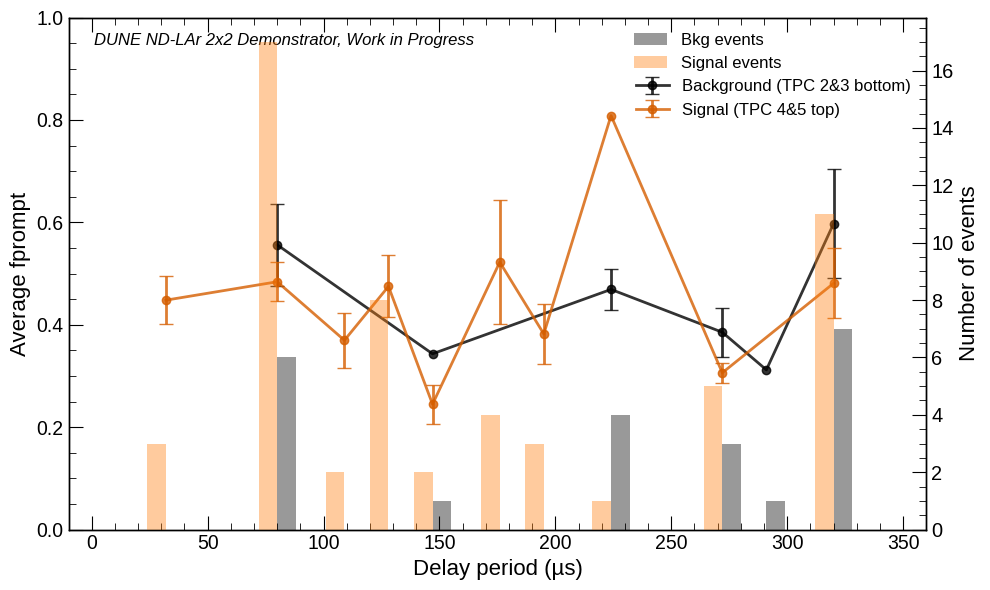

In [64]:
# ── Mean fprompt vs delay period (delayed window, signal vs background) ────────
two_trig = events_all[events_all["period"].isin(PERIODS)]
delayed = two_trig[(two_trig["window"] == "delayed")].dropna(subset=["fprompt"])

# Signal: top of TPC 4&5 ; Background: bottom of TPC 2&3
signal_mask = (delayed["tpc"].isin([4, 5])) & (delayed["position"] == "top")
bkg_mask    = (delayed["tpc"].isin([2, 3])) & (delayed["position"] == "bottom")

sig = delayed[signal_mask]
bkg = delayed[bkg_mask]

def mean_with_err(df, col="fprompt"):
    g = df.groupby("period")[col]
    mean = g.mean()
    err  = g.std() / np.sqrt(g.size())
    n    = g.size()
    return mean, err, n

sig_mean, sig_err, sig_n = mean_with_err(sig)
bkg_mean, bkg_err, bkg_n = mean_with_err(bkg)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(bkg_mean.index, bkg_mean, yerr=bkg_err, capsize=5, marker="o", color="white", label="  ", zorder=500, alpha=0.0)
ax.errorbar(bkg_mean.index, bkg_mean, yerr=bkg_err, capsize=5, marker="o", color="white", label="   ", zorder=500, alpha=0.0)
ax.errorbar(bkg_mean.index, bkg_mean, yerr=bkg_err, capsize=5, marker="o",
            label="Background (TPC 2&3 bottom)", zorder=50, alpha=0.8)
ax.errorbar(sig_mean.index, sig_mean, yerr=sig_err, capsize=5, marker="o",
            label="Signal (TPC 4&5 top)", zorder=100, alpha=0.8)

ax.set_ylim(0, 1)
ax.set_xlim(-10, 360)
ax.set_ylabel("Average fprompt", fontsize=16)
ax.set_xlabel("Delay period (µs)", fontsize=16)
ax.tick_params(axis="both", direction="in", labelsize=14)

ax2 = ax.twinx()
width = 8
ax2.bar(bkg_n.index + width/2, bkg_n, width=width, color="black",   alpha=0.4, label="Bkg events                                ")
ax2.bar(sig_n.index - width/2, sig_n, width=width, color="tab:orange", alpha=0.4, label="Signal events                   ")

ax2.set_ylabel("Number of events", fontsize=16)
# ax2.tick_params(axis="both", direction="in", labelsize=14)
ax2.legend(fontsize=12, loc="upper right")
ax.legend(fontsize=12, loc="upper right")
dune_label(ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "mean_fprompt_vs_period.png"), dpi=350, bbox_inches="tight")
plt.show()

/tmp/ipykernel_411502/2567390241.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eff = two_trig.groupby(["period", "window"]).apply(


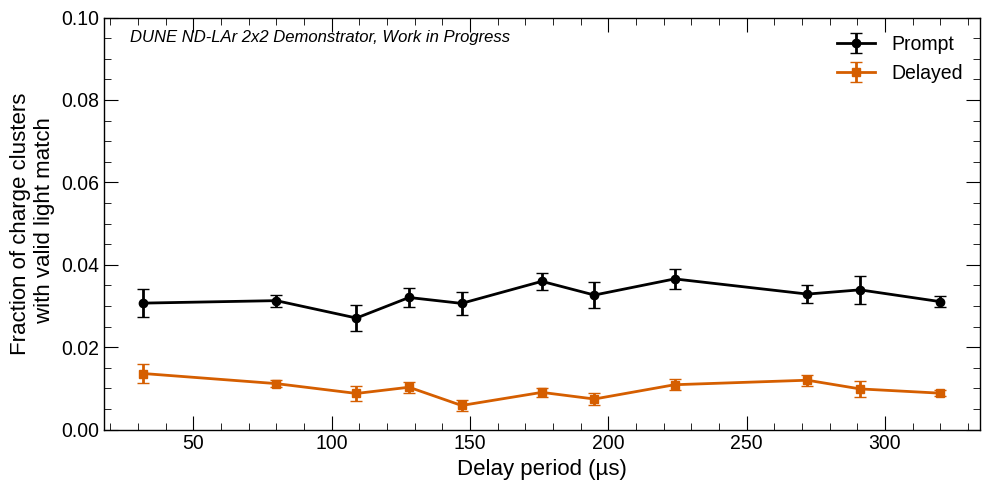

In [67]:
# ── CL matching efficiency vs period ──────────────────────────────────────────
two_trig = events_all[events_all["period"].isin(PERIODS)]

eff = two_trig.groupby(["period", "window"]).apply(
    lambda g: pd.Series({
        "n_total": len(g),
        "n_light": g["fprompt"].notna().sum(),
    })
).reset_index()
eff["efficiency"] = eff["n_light"] / eff["n_total"]
eff["eff_err"] = np.sqrt(eff["efficiency"] * (1 - eff["efficiency"]) / eff["n_total"])

fig, ax = plt.subplots(figsize=(10, 5))
for window, marker in [("prompt", "o"), ("delayed", "s")]:
    sub = eff[eff["window"] == window]
    ax.errorbar(sub["period"], sub["efficiency"], yerr=sub["eff_err"],
                marker=marker, capsize=4, label=window.capitalize())
ax.set_xlabel("Delay period (µs)", fontsize=16)
ax.set_ylabel("Fraction of charge clusters\n with valid light match", fontsize=16)
ax.tick_params(axis="both", direction="in", labelsize=14)
ax.set_ylim(0, 0.1)
ax.legend(fontsize=14)
dune_label(ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "cl_matching_efficiency.png"), dpi=150, bbox_inches="tight")
plt.show()

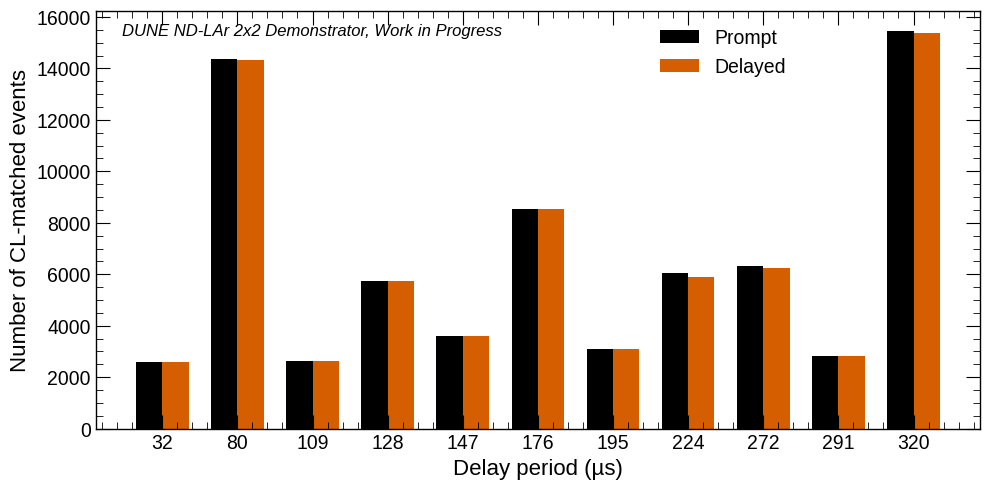

In [62]:
# ── Event counts per period ───────────────────────────────────────────────────
two_trig = events_all[events_all["period"].isin(PERIODS)]
counts = two_trig.groupby(["period", "window"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(counts))
width = 0.35
if "prompt" in counts.columns:
    ax.bar(x - width/2, counts["prompt"], width, label="Prompt")
if "delayed" in counts.columns:
    ax.bar(x + width/2, counts["delayed"], width, label="Delayed")
ax.set_xticks(x)
ax.set_xticklabels(counts.index, fontsize=12)
ax.set_xlabel("Delay period (µs)", fontsize=16)
ax.set_ylabel("Number of CL-matched events", fontsize=16)
ax.tick_params(axis="both", direction="in", labelsize=14)
ax.legend(fontsize=14, bbox_to_anchor=(0.8, 1))
dune_label(ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "event_counts_per_period.png"), dpi=350, bbox_inches="tight")
plt.show()

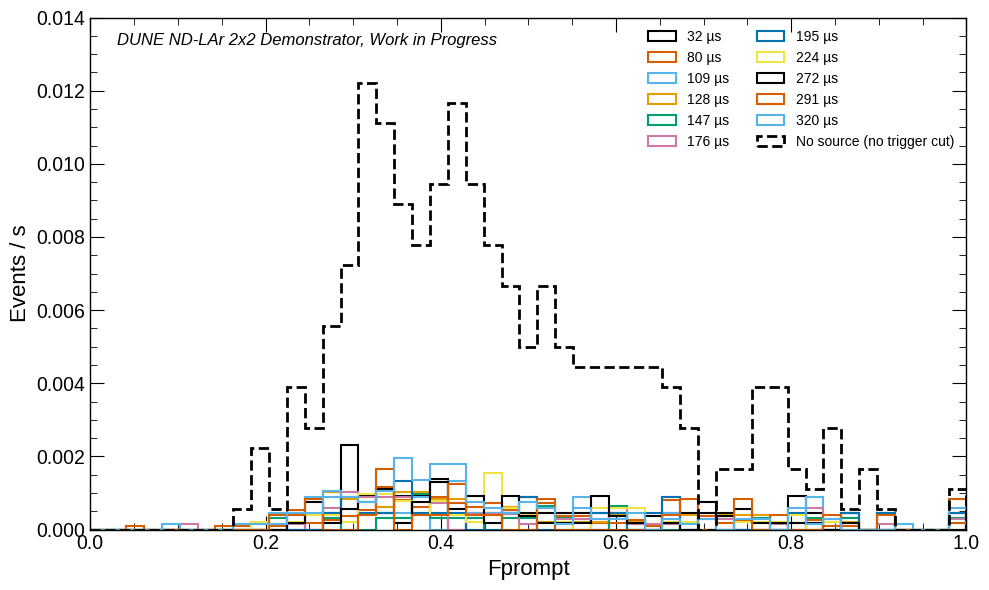

In [61]:
# ── Fprompt distributions overlaid per period (delayed window), normalized by exposure ──
delayed_valid = events_all[(events_all["window"] == "delayed")].dropna(subset=["fprompt"])
bins_fp = np.linspace(0, 1, 50)

fig, ax = plt.subplots(figsize=(10, 6))
for period in PERIODS:
    sub = delayed_valid[delayed_valid["period"] == period]
    if len(sub) > 0:
        exp_s = exposure[period]
        ax.hist(sub["fprompt"], bins=bins_fp, histtype="step",
                weights=np.ones(len(sub)) / exp_s,
                label=f"{period} µs", linewidth=1.5)

# Background overlay (all light from no_source files, unmatched)
exp_bkg = exposure["no_source"]
ax.hist(bkg_light_df["fprompt"], bins=bins_fp, histtype="step",
        weights=np.ones(len(bkg_light_df)) / exp_bkg,
        label="No source (no trigger cut)", linewidth=2, linestyle="--", color="black")

ax.set_xlabel("Fprompt", fontsize=16)
ax.set_ylabel("Events / s", fontsize=16)
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.014)
ax.tick_params(axis="both", direction="in", labelsize=14)
ax.legend(fontsize=10, ncol=2)
dune_label(ax)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "fprompt_per_period_delayed.png"), dpi=350, bbox_inches="tight")
plt.show()

<cell_type>markdown</cell_type>## Combined prompt analysis: multi-trigger vs one-trigger vs combined

For each charge hit cut, shows three contributions overlaid:
- **Two-trig prompt** (all delay periods)
- **One-trig 32 µs** (Edgar's source data)
- **Combined** (sum of both)

Plus no-source background where applicable. Edit `DUNE_POS` and `CHARGE_HIT_CUTS` in the config cell to customize.

In [48]:
# ── Plotting helpers for multi-contribution prompt figures ─────────────────────

def get_prompt_subsets(events_all, cut):
    """Split prompt events into two-trig, one-trig, and combined, applying charge hit cut."""
    prompt = events_all[(events_all["window"] == "prompt")].dropna(subset=["fprompt"])
    if cut > 0:
        prompt = prompt[prompt["n_charge_hits"] > cut]
    two_trig = prompt[prompt["period"] != "one_trig"]
    one_trig = prompt[prompt["period"] == "one_trig"]
    return two_trig, one_trig, prompt

def get_prompt_exposures(two_trig, one_trig, combined):
    """Calculate total exposure for each subset."""
    exp_tt = sum(exposure[p] for p in two_trig["period"].unique() if p in exposure)
    exp_ot = exposure.get("one_trig", 0)
    exp_comb = exp_tt + exp_ot
    return exp_tt, exp_ot, exp_comb

# ── DUNE label positions per plot — edit these to taste ───────────────────────
# Keys: (plot_type, cut). If a specific (type, cut) isn't found, falls back to (type,).
# Values: dict of kwargs passed to dune_label(ax, **kwargs)
DUNE_POS = {
    ("fprompt",):     dict(loc="upper left"),
    ("integral",):    dict(loc="upper right"),
    ("charge_E",):    dict(loc="upper right"),
    ("spatial",):     dict(loc="upper left"),
    ("2d",):          dict(loc="upper left"),
}

def get_dune_kwargs(plot_type, cut=None):
    key = (plot_type, cut)
    if key in DUNE_POS:
        return DUNE_POS[key]
    return DUNE_POS.get((plot_type,), dict(loc="upper left"))


  no charge hit cut
  Two-trig prompt: 2306 events, exposure 14.5 h
  One-trig 32 µs:  657 events, exposure 1.6 h
  Combined:        2963 events, exposure 16.1 h
  Background:      314 light / 1067 charge, exposure 0.5 h


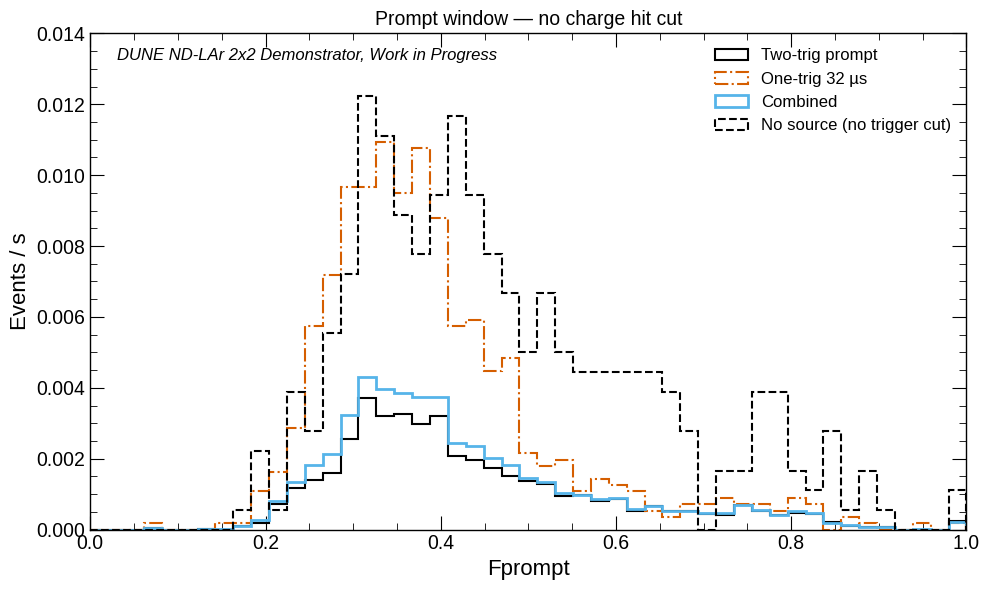

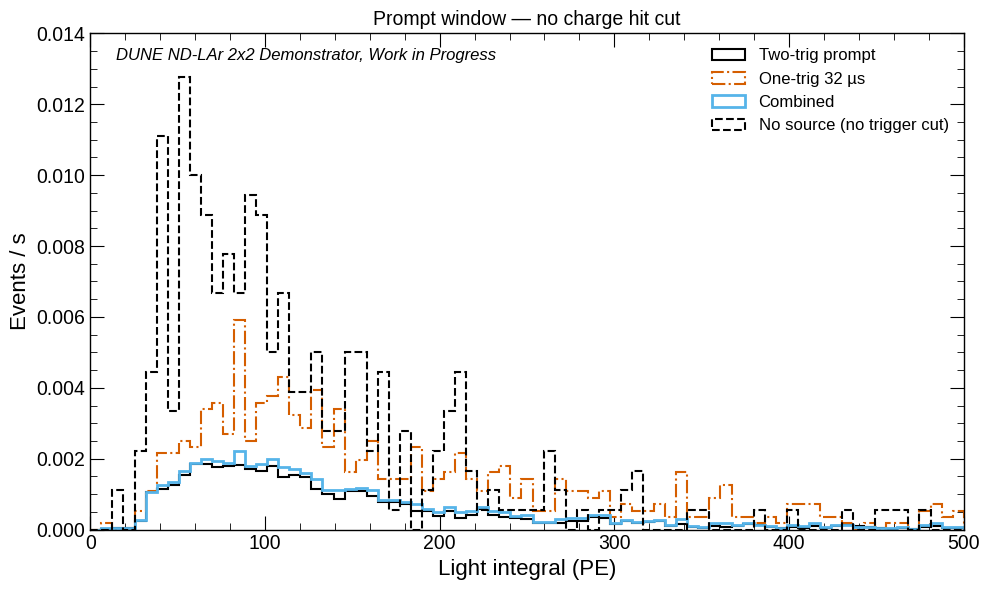

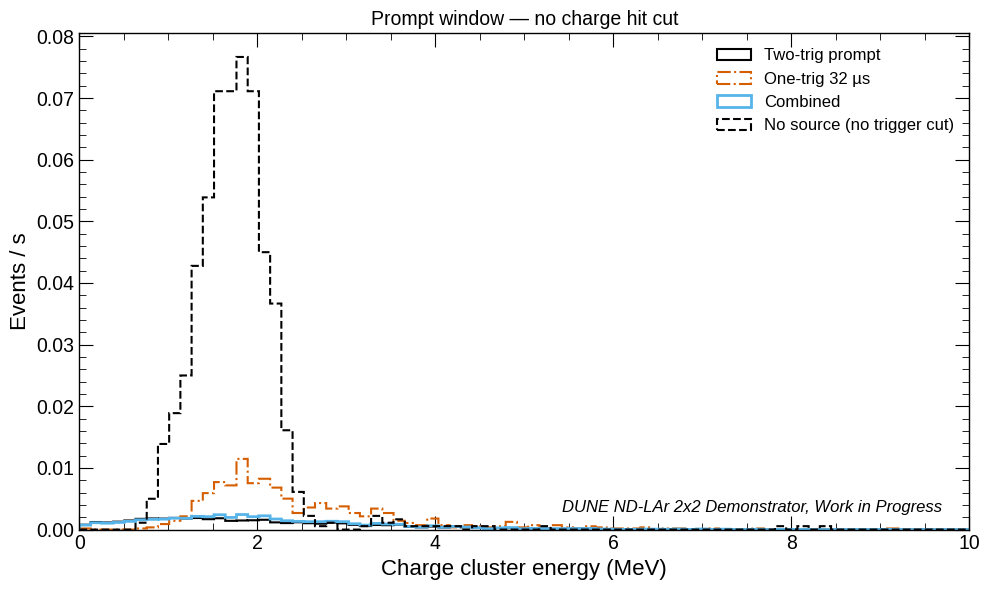

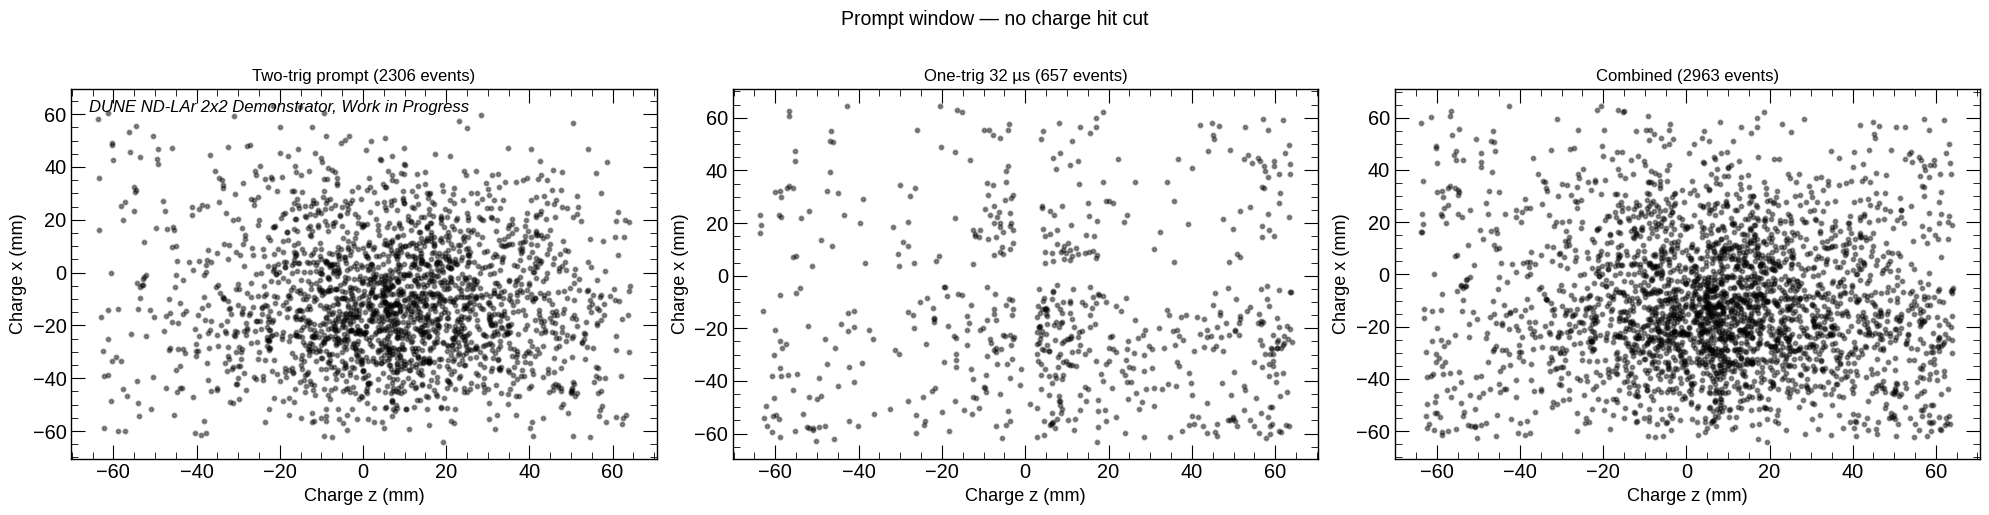


  n_charge_hits > 3
  Two-trig prompt: 1677 events, exposure 14.5 h
  One-trig 32 µs:  657 events, exposure 1.6 h
  Combined:        2334 events, exposure 16.1 h
  Background:      314 light / 1067 charge, exposure 0.5 h


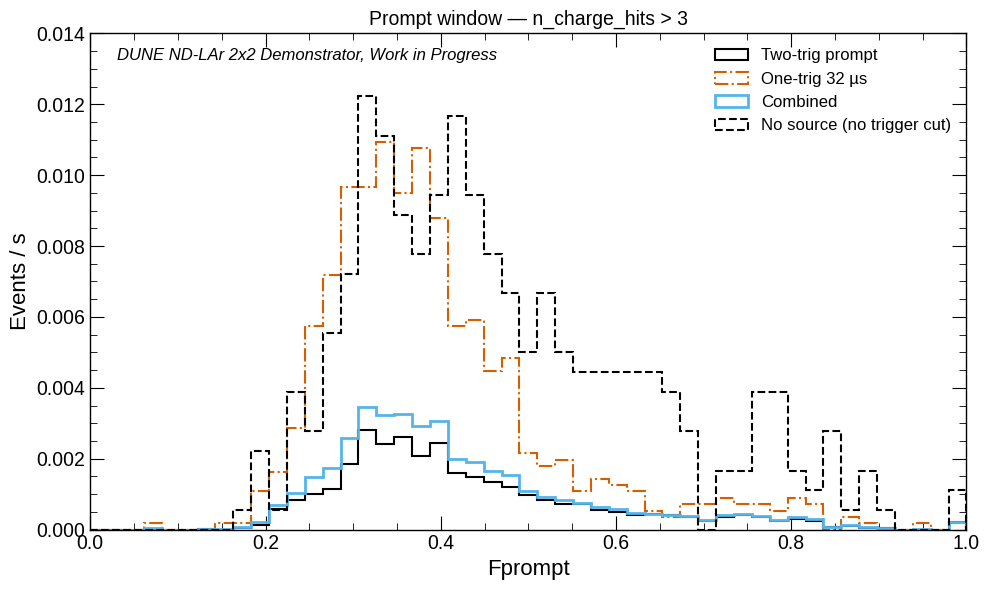

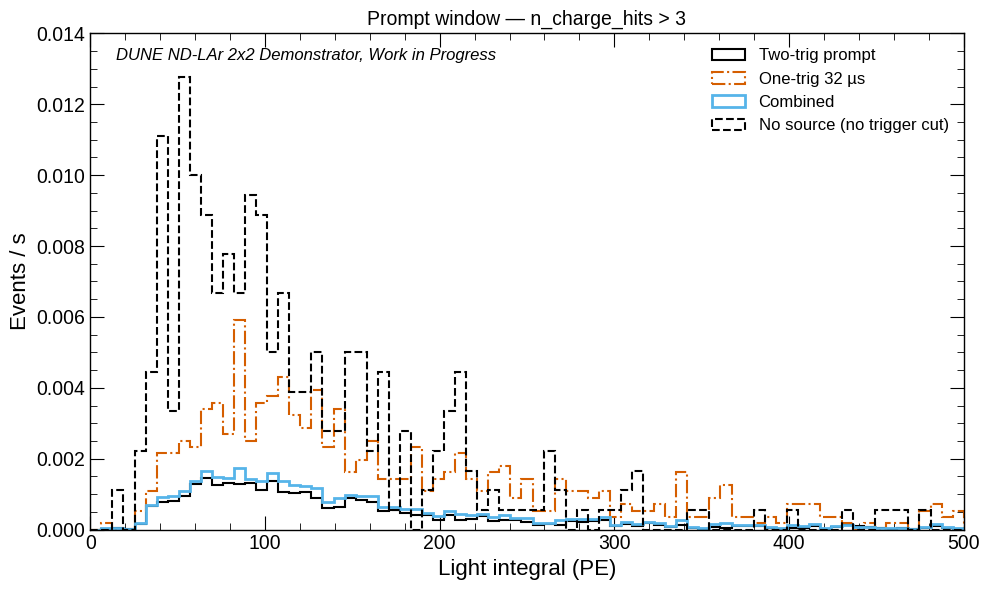

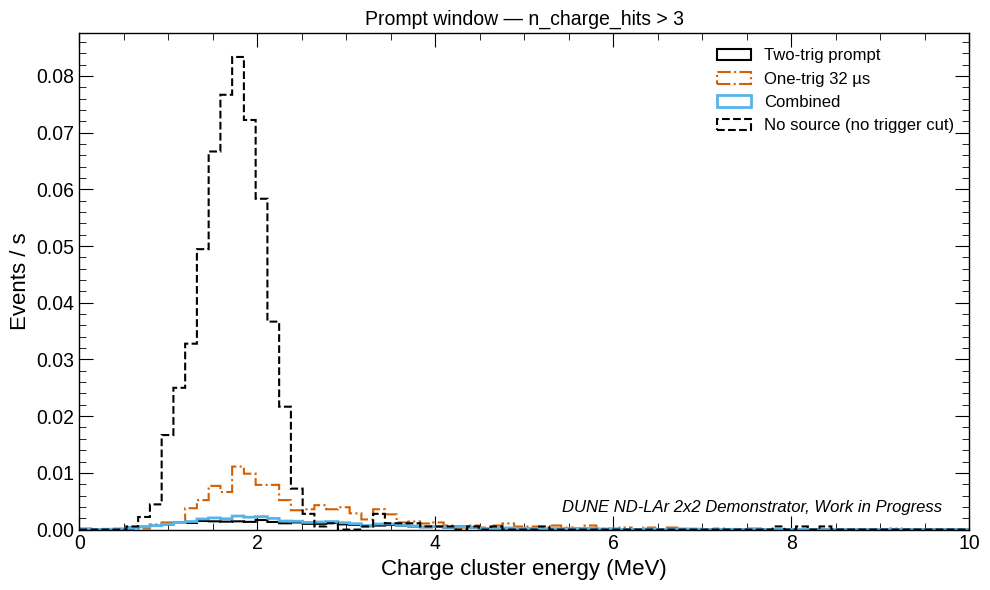

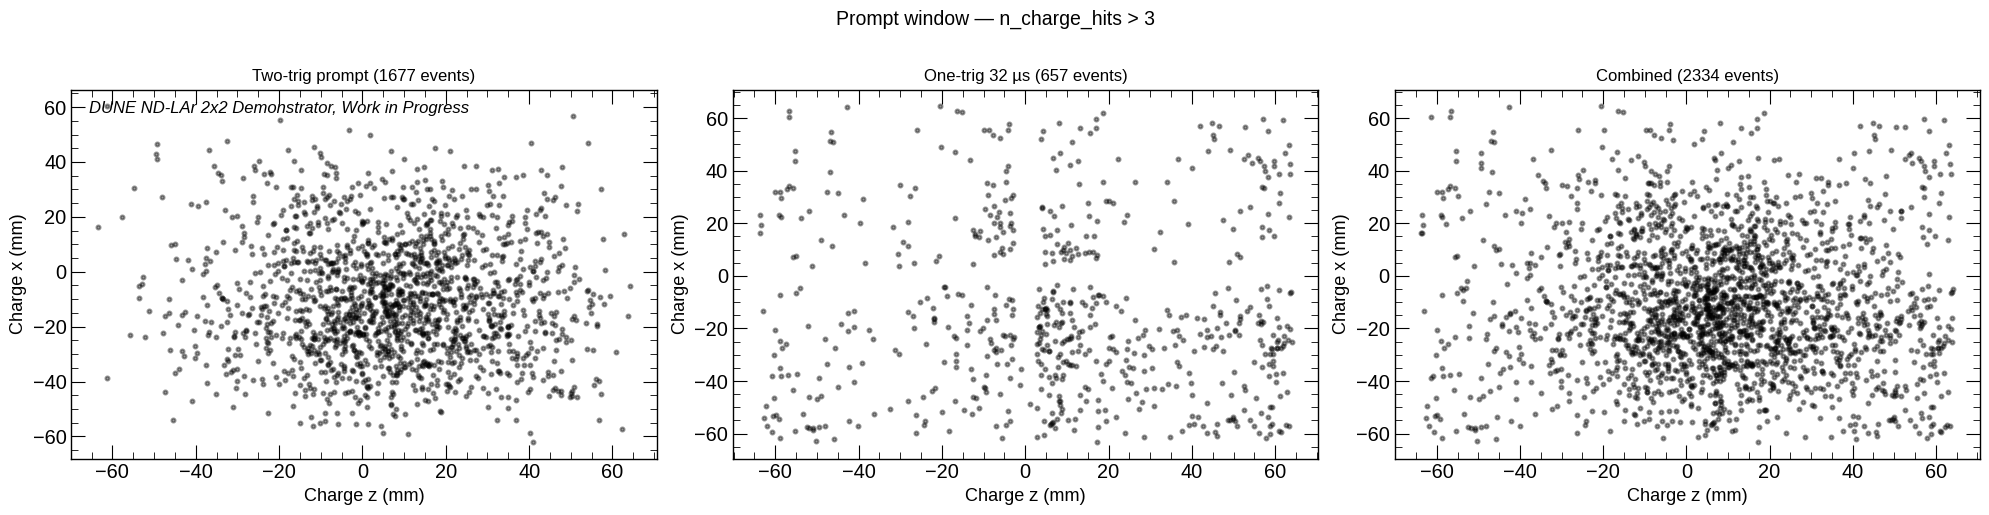

In [60]:
# ── Prompt distribution figures: three contributions + background ──────────────
exp_bkg = exposure["no_source"]

for cut in CHARGE_HIT_CUTS:
    two_trig, one_trig, combined = get_prompt_subsets(events_all, cut)
    exp_tt, exp_ot, exp_comb = get_prompt_exposures(two_trig, one_trig, combined)

    cut_label = f"n_charge_hits > {cut}" if cut > 0 else "no charge hit cut"
    cut_tag = f"cut{cut}"
    print(f"\n{'='*60}")
    print(f"  {cut_label}")
    print(f"  Two-trig prompt: {len(two_trig)} events, exposure {exp_tt/3600:.1f} h")
    print(f"  One-trig 32 µs:  {len(one_trig)} events, exposure {exp_ot/3600:.1f} h")
    print(f"  Combined:        {len(combined)} events, exposure {exp_comb/3600:.1f} h")
    print(f"  Background:      {len(bkg_light_df)} light / {len(bkg_charge_df)} charge, exposure {exp_bkg/3600:.1f} h")
    print(f"{'='*60}")

    subsets = [
        ("Two-trig prompt", two_trig, exp_tt, dict(linewidth=1.5)),
        ("One-trig 32 µs",  one_trig, exp_ot, dict(linewidth=1.5, linestyle="-.")),
        ("Combined",        combined, exp_comb, dict(linewidth=2.0)),
    ]

    # ── 1. Fprompt ────────────────────────────────────────────────────────────
    bins_fp = np.linspace(0, 1, 50)
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, df, exp_s, kw in subsets:
        if len(df) == 0:
            continue
        ax.hist(df["fprompt"], bins=bins_fp, histtype="step",
                weights=np.ones(len(df)) / exp_s, label=label, **kw)
    ax.hist(bkg_light_df["fprompt"], bins=bins_fp, histtype="step",
            weights=np.ones(len(bkg_light_df)) / exp_bkg,
            label="No source (no trigger cut)", linewidth=1.5, linestyle="--", color="black")
    ax.set_xlabel("Fprompt", fontsize=16)
    ax.set_ylabel("Events / s", fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.014)
    ax.tick_params(axis="both", direction="in", labelsize=14)
    ax.legend(fontsize=12)
    ax.set_title(f"Prompt window — {cut_label}", fontsize=14)
    dune_label(ax, **get_dune_kwargs("fprompt", cut))
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"prompt_fprompt_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

    # ── 2. Light integral ─────────────────────────────────────────────────────
    bins_int = np.linspace(0, 500, 80)
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, df, exp_s, kw in subsets:
        if len(df) == 0:
            continue
        ax.hist(df["integral"], bins=bins_int, histtype="step",
                weights=np.ones(len(df)) / exp_s, label=label, **kw)
    ax.hist(bkg_light_df["integral"], bins=bins_int, histtype="step",
            weights=np.ones(len(bkg_light_df)) / exp_bkg,
            label="No source (no trigger cut)", linewidth=1.5, linestyle="--", color="black")
    ax.set_xlabel("Light integral (PE)", fontsize=16)
    ax.set_ylabel("Events / s", fontsize=16)
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 0.014)
    ax.tick_params(axis="both", direction="in", labelsize=14)
    ax.legend(fontsize=12)
    ax.set_title(f"Prompt window — {cut_label}", fontsize=14)
    dune_label(ax, loc="upper left")
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"prompt_integral_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

    # ── 3. Charge cluster energy ──────────────────────────────────────────────
    q98 = combined["charge_E"].quantile(0.98) if len(combined) > 0 else 10
    bins_E = np.linspace(0, q98, 800)
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, df, exp_s, kw in subsets:
        if len(df) == 0:
            continue
        ax.hist(df["charge_E"], bins=bins_E, histtype="step",
                weights=np.ones(len(df)) / exp_s, label=label, **kw)
    # Background charge (apply same cut)
    bkg_ch = bkg_charge_df[bkg_charge_df["n_charge_hits"] > cut] if cut > 0 else bkg_charge_df
    if len(bkg_ch) > 0:
        ax.hist(bkg_ch["charge_E"], bins=bins_E, histtype="step",
                weights=np.ones(len(bkg_ch)) / exp_bkg,
                label="No source (no trigger cut)", linewidth=1.5, linestyle="--", color="black")
    ax.set_xlabel("Charge cluster energy (MeV)", fontsize=16)
    ax.set_ylabel("Events / s", fontsize=16)
    ax.tick_params(axis="both", direction="in", labelsize=14)
    ax.legend(fontsize=12)
    ax.set_xlim(0, 10)
    ax.set_title(f"Prompt window — {cut_label}", fontsize=14)
    dune_label(ax, loc="lower right")
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"prompt_charge_E_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

    # ── 4. Spatial x-z scatter ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, (label, df, _, _) in zip(axes, subsets):
        if len(df) > 0:
            ax.scatter(df["charge_z"], df["charge_x"], s=8, alpha=0.4)
        ax.set_xlabel("Charge z (mm)", fontsize=13)
        ax.set_ylabel("Charge x (mm)", fontsize=13)
        ax.set_title(f"{label} ({len(df)} events)", fontsize=12)
        ax.tick_params(direction="in")
    dune_label(axes[0], **get_dune_kwargs("spatial", cut))
    fig.suptitle(f"Prompt window — {cut_label}", fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"prompt_spatial_xz_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

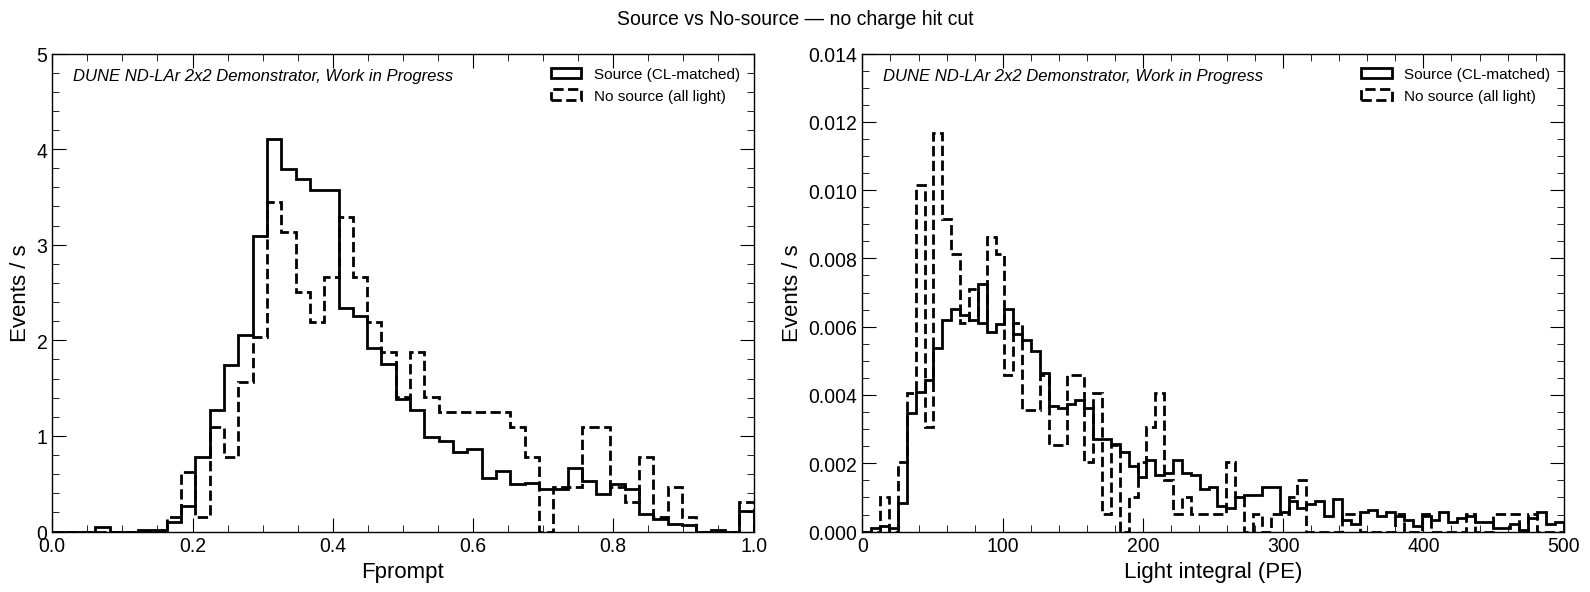

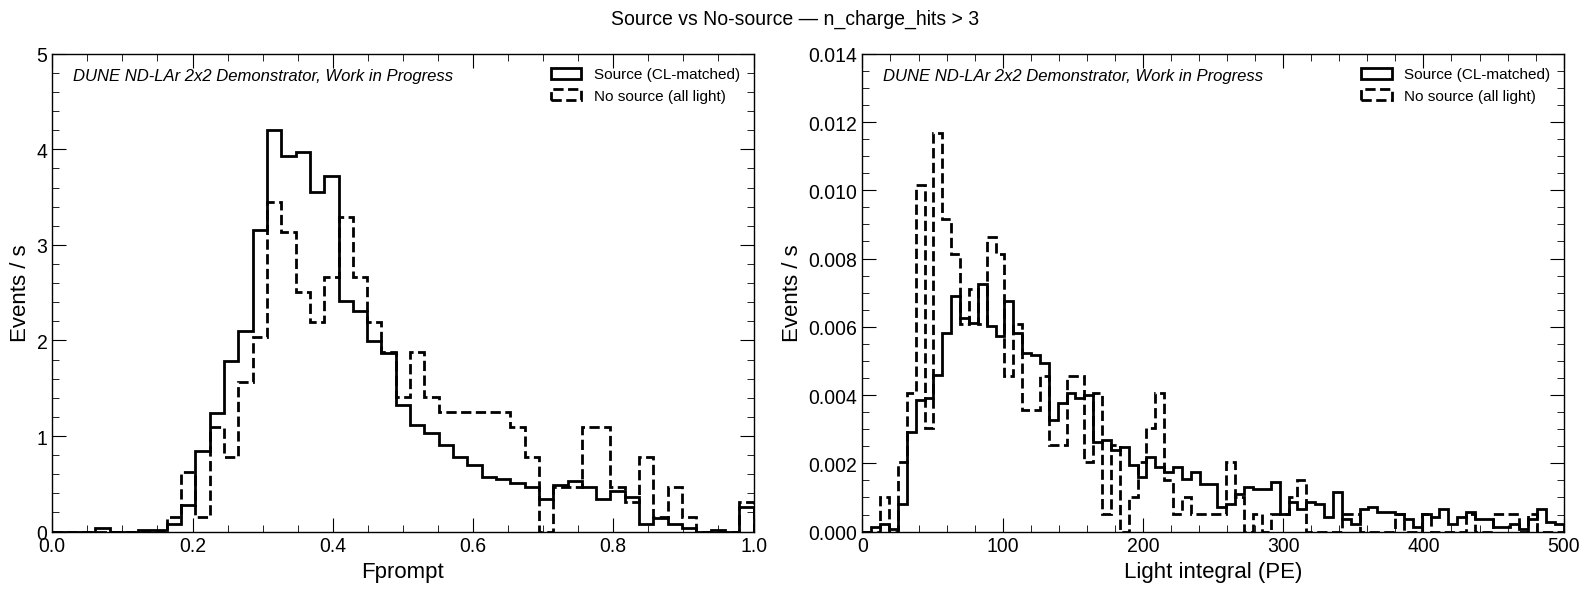

In [85]:
# ── Simple source vs background: fprompt and integral (no contribution split) ─
# All source CL-matched prompt events lumped together vs all no-source light

for cut in CHARGE_HIT_CUTS:
    _, _, combined = get_prompt_subsets(events_all, cut)
    _, _, exp_comb = get_prompt_exposures(*get_prompt_subsets(events_all, cut))
    cut_label = f"n_charge_hits > {cut}" if cut > 0 else "no charge hit cut"
    cut_tag = f"cut{cut}"

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Fprompt
    bins_fp = np.linspace(0, 1, 50)
    axes[0].hist(combined["fprompt"], bins=bins_fp, histtype="step", linewidth=2,
                 weights=np.ones(len(combined)) / exp_comb, label=f"Source (CL-matched)", density=True)
    axes[0].hist(bkg_light_df["fprompt"], bins=bins_fp, histtype="step", linewidth=2,
                 weights=np.ones(len(bkg_light_df)) / exp_bkg,
                 linestyle="--", color="black", label=f"No source (all light)",density=True)
    axes[0].set_xlabel("Fprompt", fontsize=16)
    axes[0].set_ylabel("Events / s", fontsize=16)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 5)
    axes[0].tick_params(axis="both", direction="in", labelsize=14)
    axes[0].legend(fontsize=11)
    dune_label(axes[0], **get_dune_kwargs("fprompt", cut))

    # Integral
    bins_int = np.linspace(0, 500, 80)
    axes[1].hist(combined["integral"], bins=bins_int, histtype="step", linewidth=2,
                 weights=np.ones(len(combined)) / exp_comb, label=f"Source (CL-matched)", density=True)
    axes[1].hist(bkg_light_df["integral"], bins=bins_int, histtype="step", linewidth=2,
                 weights=np.ones(len(bkg_light_df)) / exp_bkg,
                 linestyle="--", color="black", label=f"No source (all light)", density=True)
    axes[1].set_xlabel("Light integral (PE)", fontsize=16)
    axes[1].set_ylabel("Events / s", fontsize=16)
    axes[1].set_xlim(0, 500)
    axes[1].set_ylim(0, 0.014)
    axes[1].tick_params(axis="both", direction="in", labelsize=14)
    axes[1].legend(fontsize=11)
    dune_label(axes[1], loc="upper left")

    fig.suptitle(f"Source vs No-source — {cut_label}", fontsize=14)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"source_vs_nosource_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

## Per-period detail plots

In [51]:
def plot_period_detail(df, period):
    """Four-panel detail plot for one period's delayed-window events."""
    valid = df.dropna(subset=["fprompt"])
    if len(valid) == 0:
        print(f"{period} µs: no events with valid light, skipping")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Delay period: {period} µs  (delayed window, {len(valid)} events with light)",
                 fontsize=16)

    # Fprompt
    axes[0, 0].hist(valid["fprompt"], bins=np.linspace(0, 1, 40), histtype="step", linewidth=1.5)
    axes[0, 0].set_xlabel("Fprompt", fontsize=13)
    axes[0, 0].set_ylabel("Events", fontsize=13)
    axes[0, 0].set_xlim(0, 1)
    axes[0, 0].tick_params(direction="in")

    # Light integral
    axes[0, 1].hist(valid["integral"], bins=np.linspace(0, 1500, 80), histtype="step", linewidth=1.5)
    axes[0, 1].set_xlabel("Light integral (PE)", fontsize=13)
    axes[0, 1].set_ylabel("Events", fontsize=13)
    axes[0, 1].set_xlim(0, 500)
    axes[0, 1].tick_params(direction="in")

    # Charge energy
    q98 = valid["charge_E"].quantile(0.98)
    axes[1, 0].hist(valid["charge_E"], bins=np.linspace(0, max(q98, 1), 60),
                    histtype="step", linewidth=1.5)
    axes[1, 0].set_xlabel("Charge cluster energy (MeV)", fontsize=13)
    axes[1, 0].set_ylabel("Events", fontsize=13)
    axes[1, 0].tick_params(direction="in")

    # Spatial distribution
    axes[1, 1].scatter(valid["charge_z"], valid["charge_x"], s=15, alpha=0.5)
    axes[1, 1].set_xlabel("Charge z (mm)", fontsize=13)
    axes[1, 1].set_ylabel("Charge x (mm)", fontsize=13)
    axes[1, 1].tick_params(direction="in")

    dune_label(axes[0, 0])
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"detail_delayed_{period}us.png"), dpi=150, bbox_inches="tight")
    plt.show()

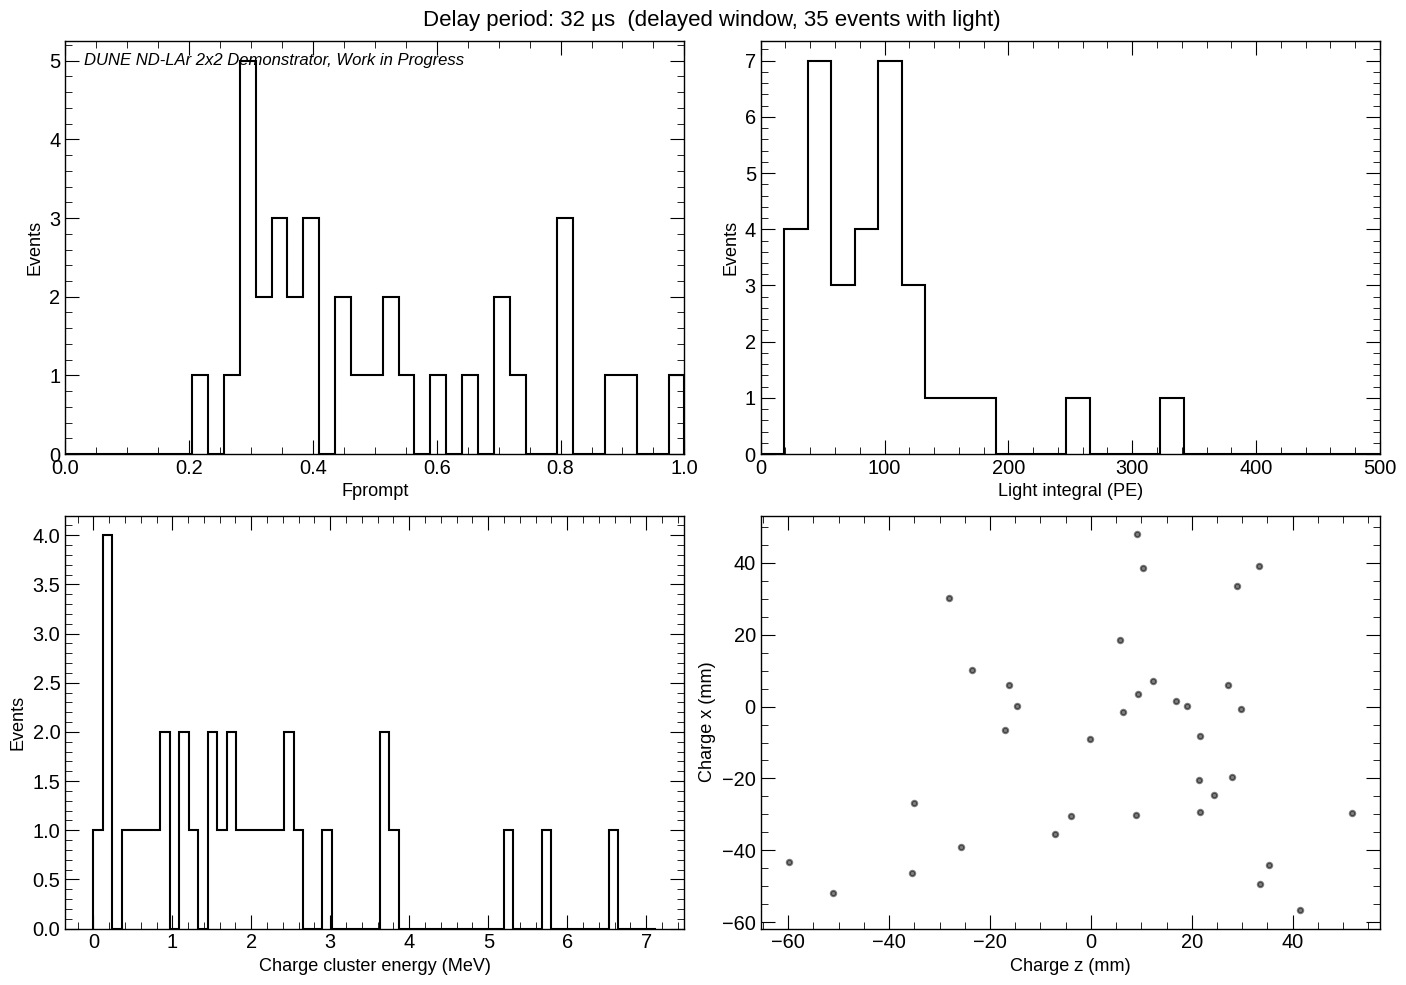

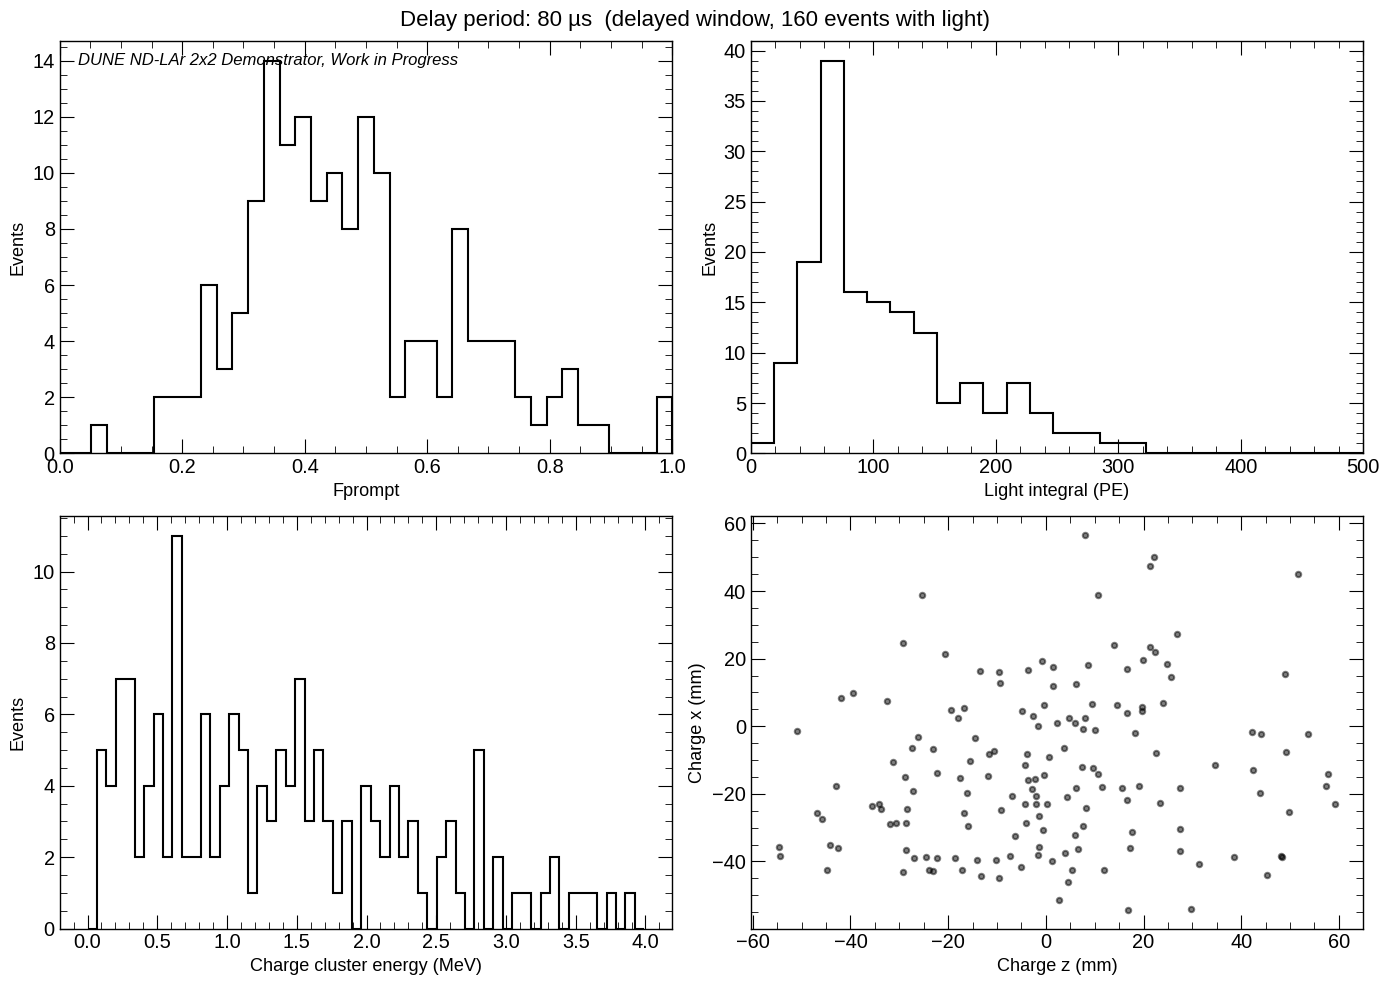

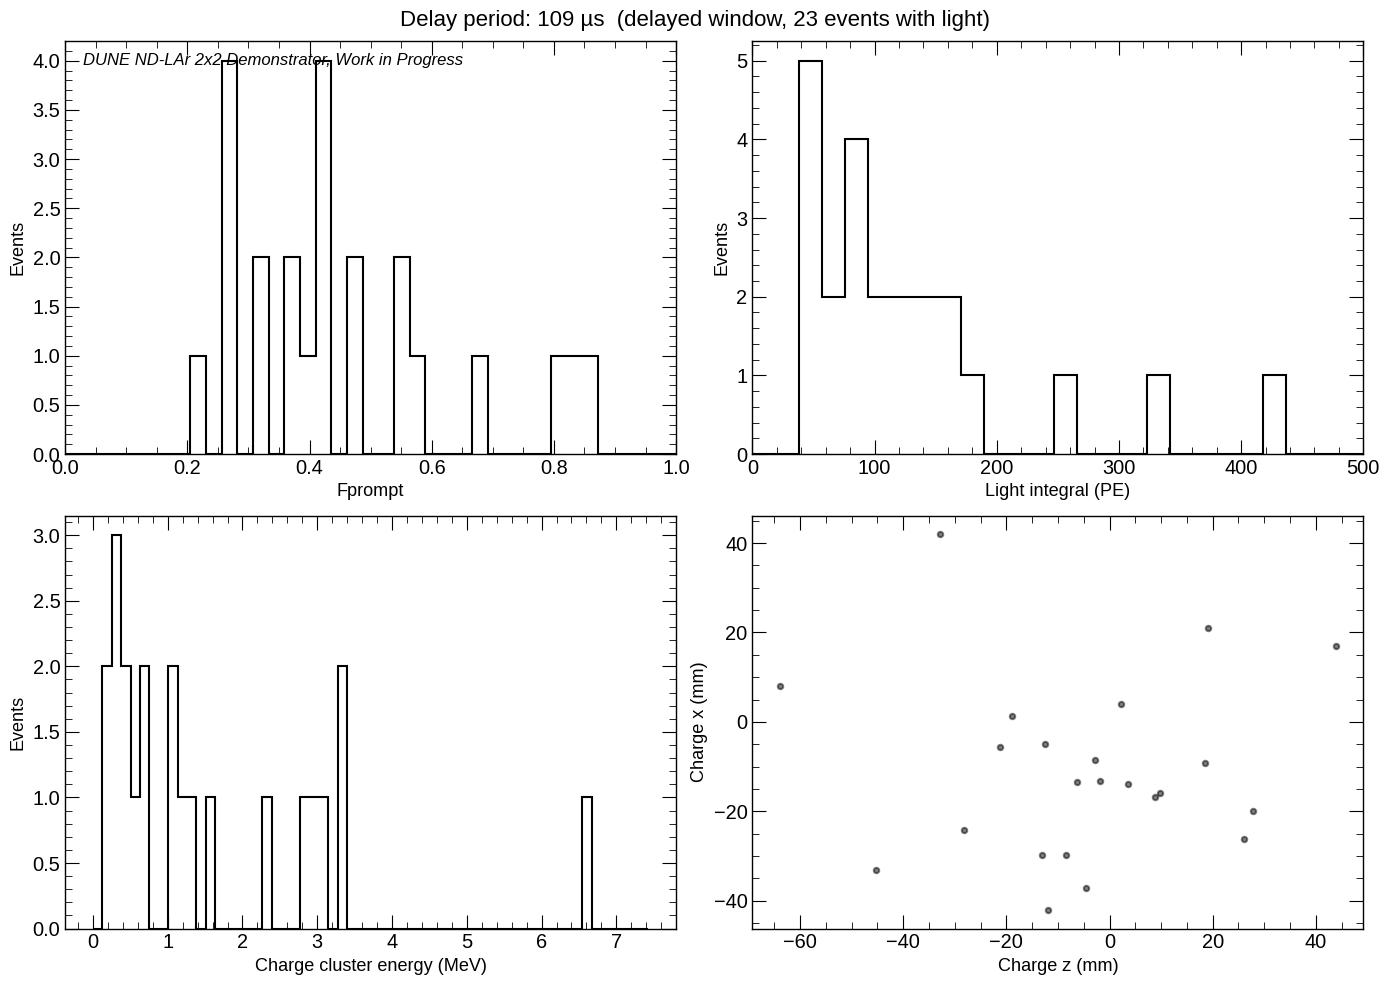

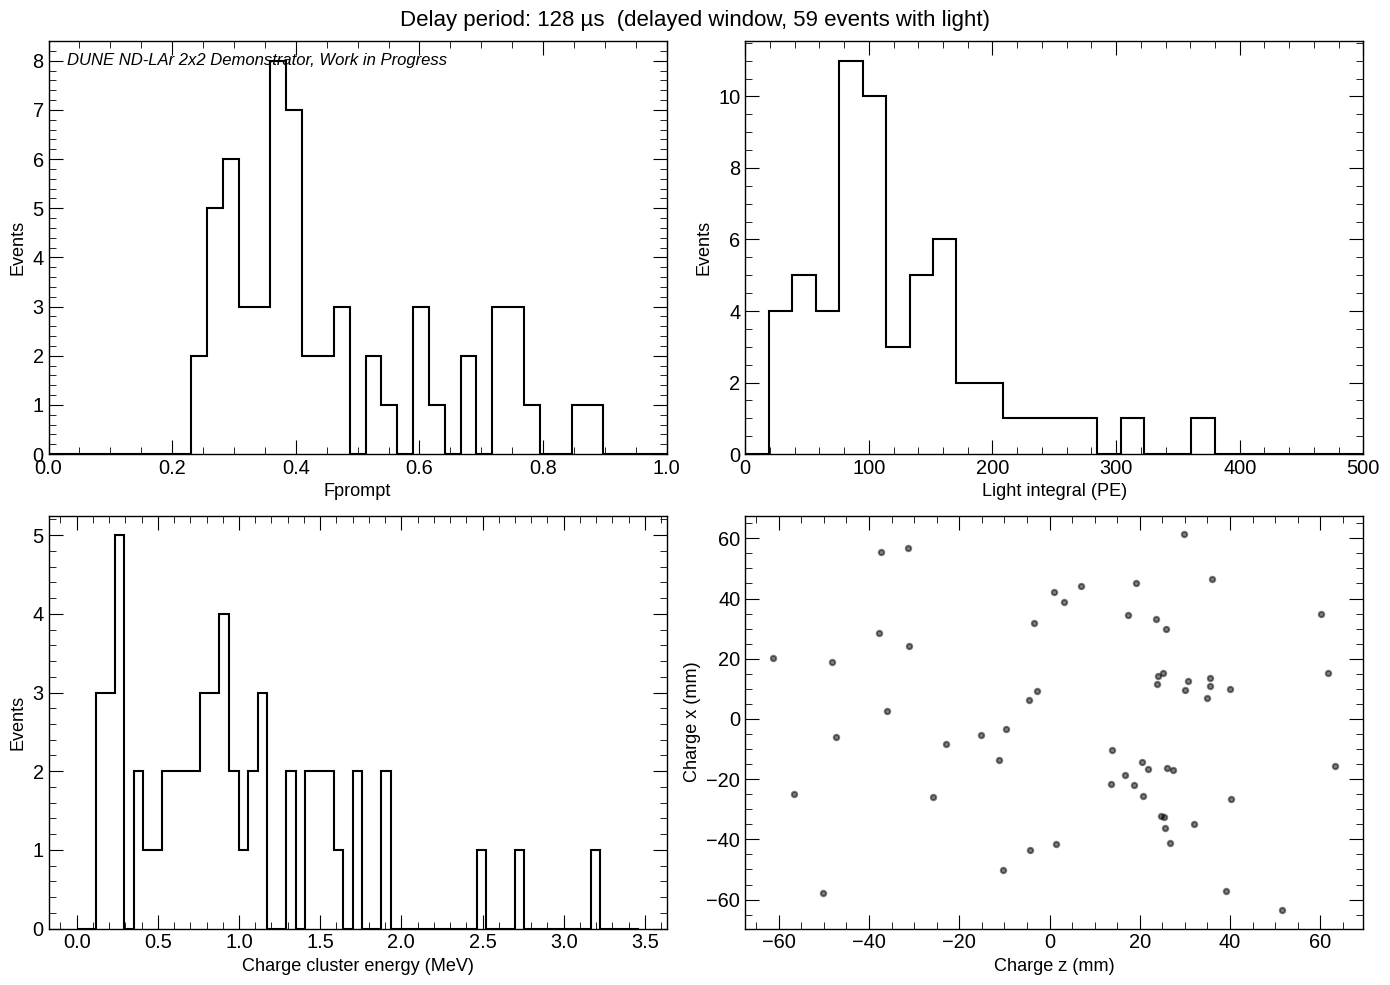

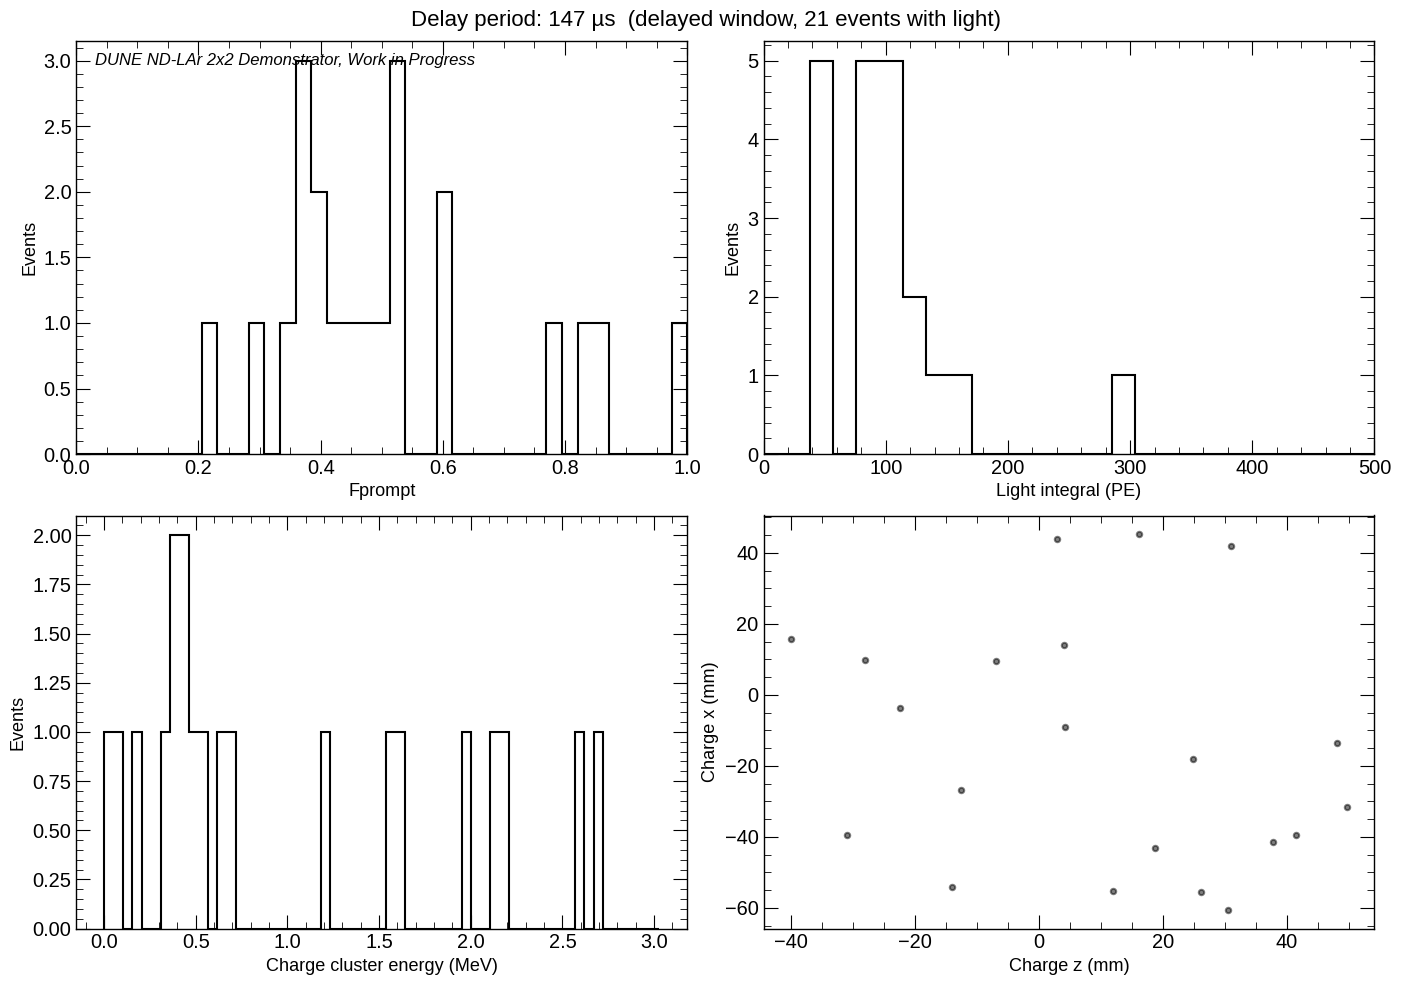

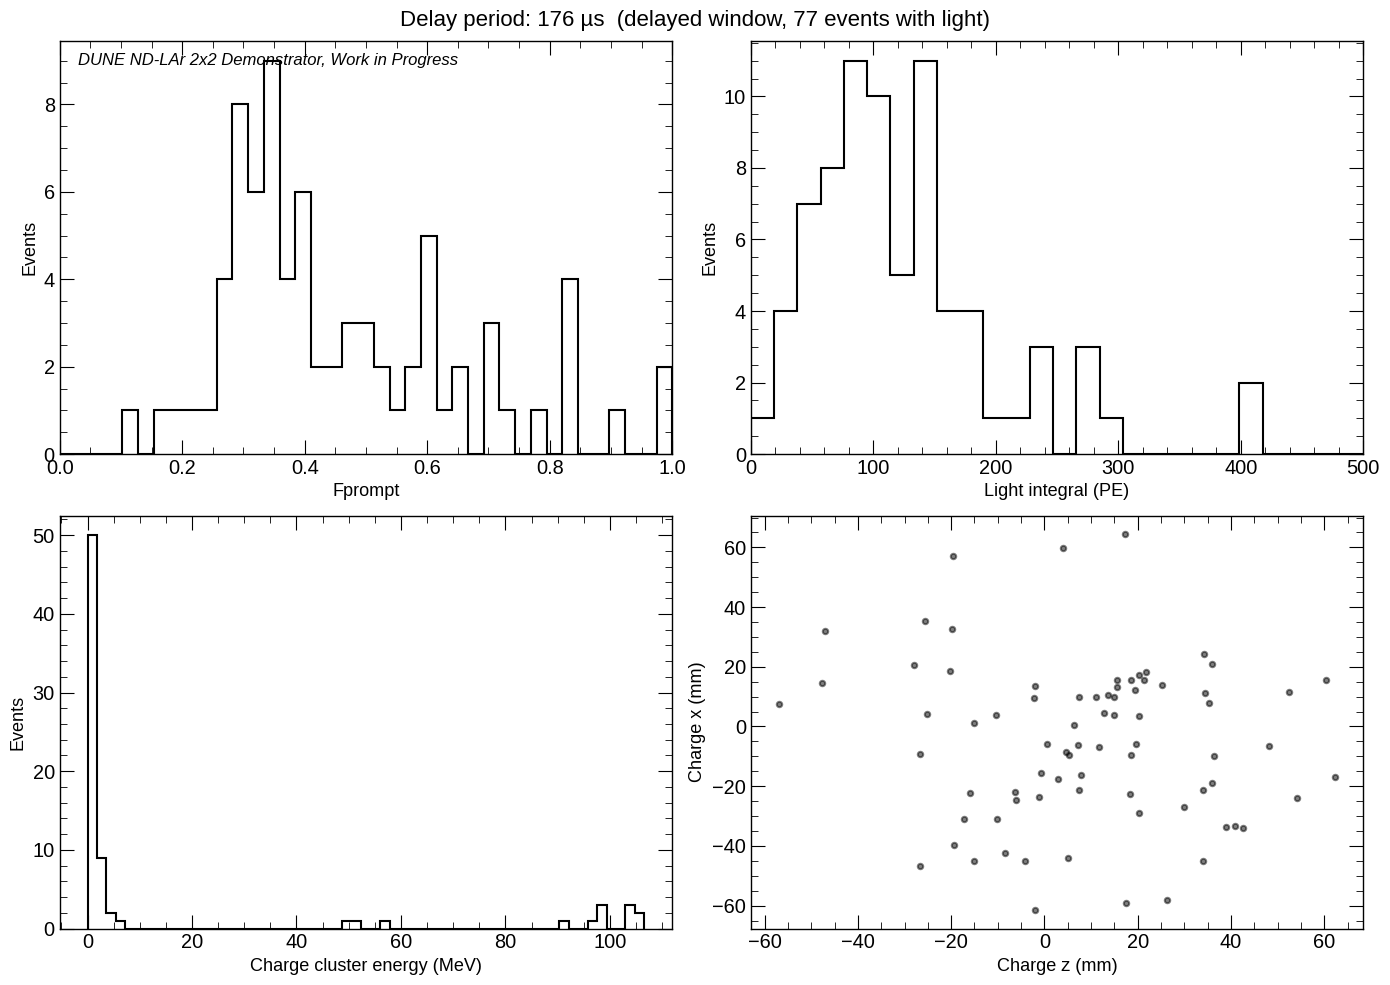

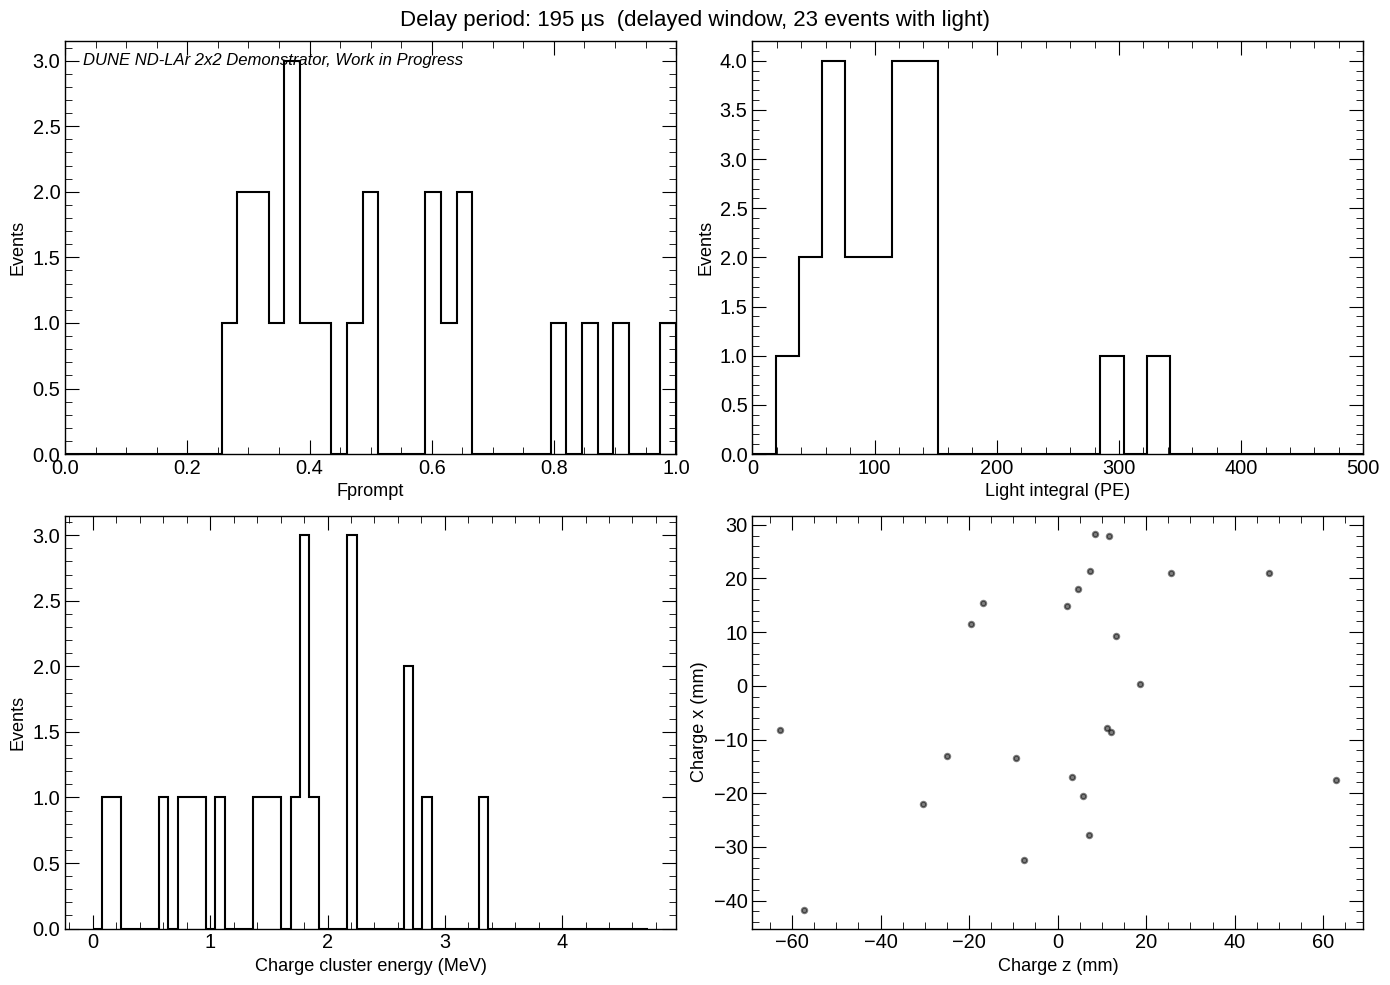

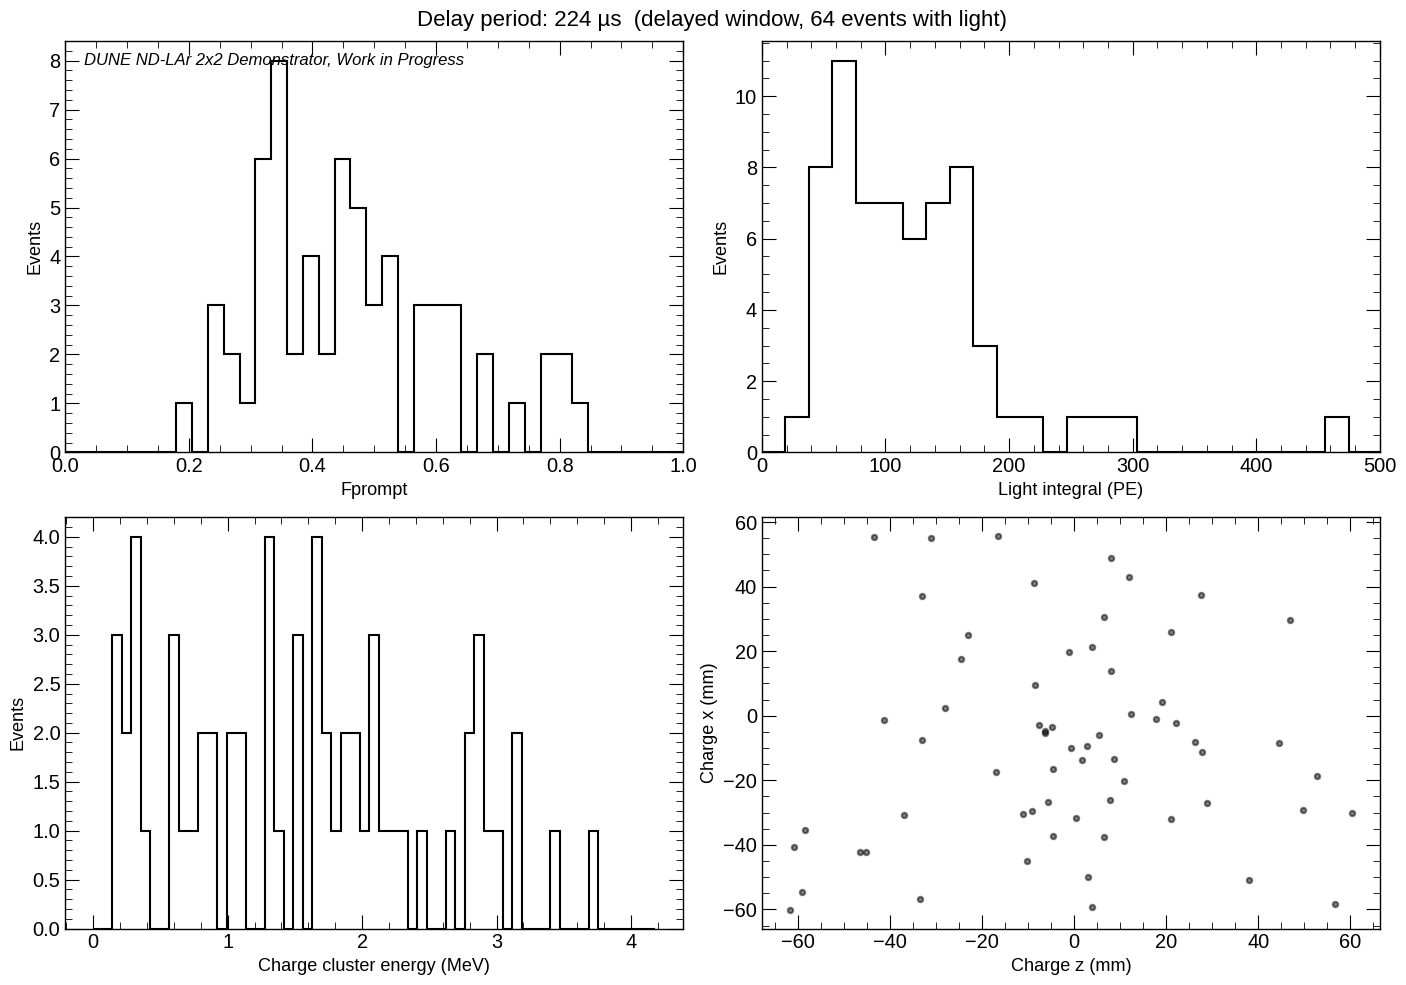

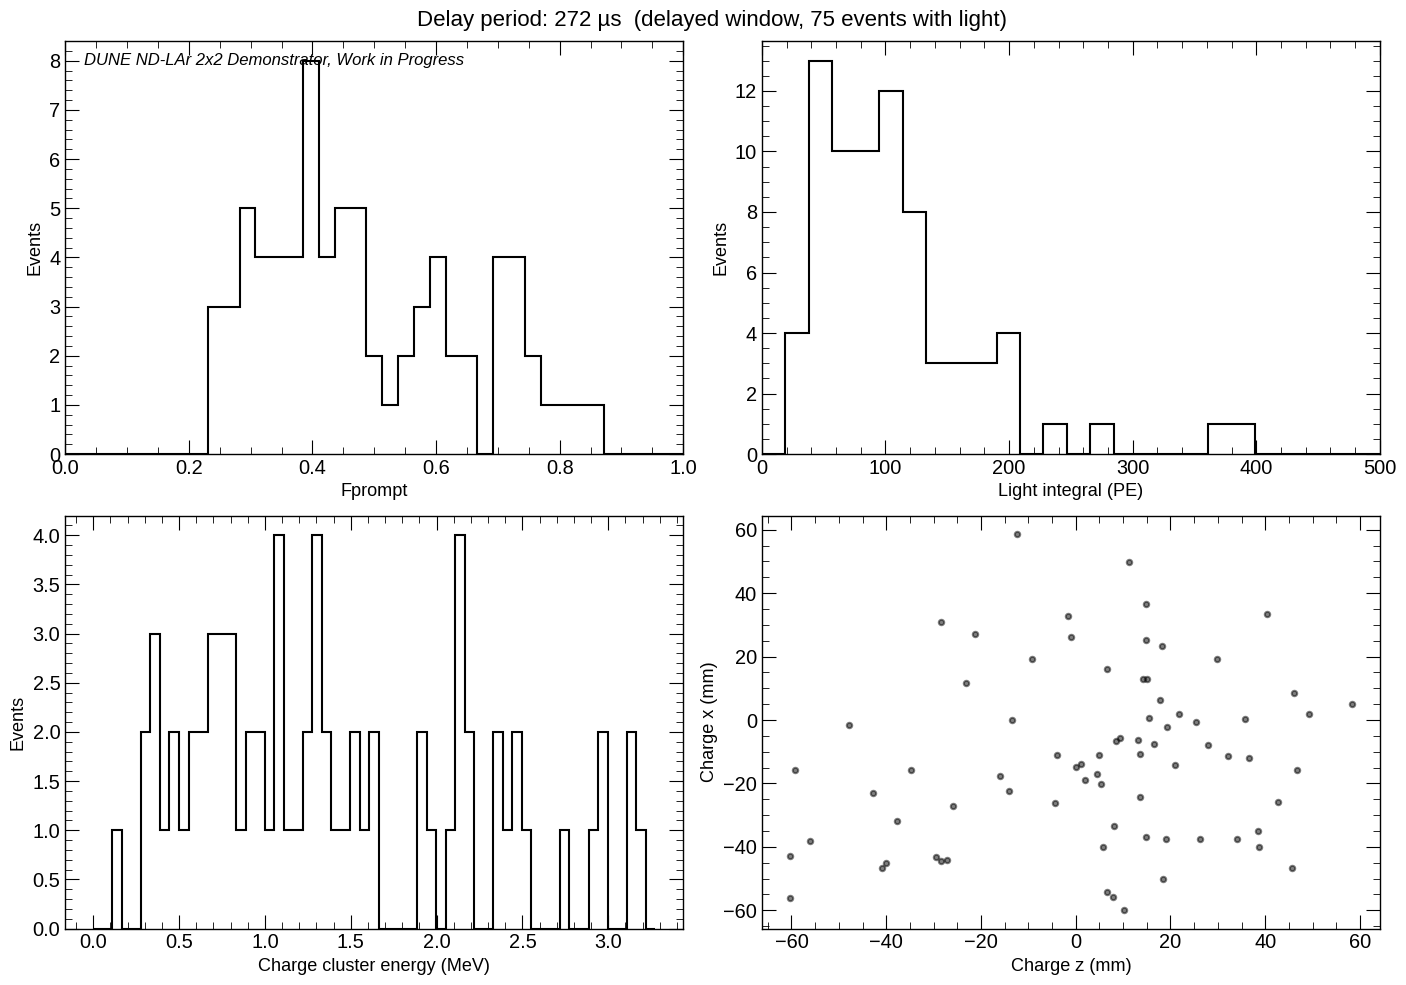

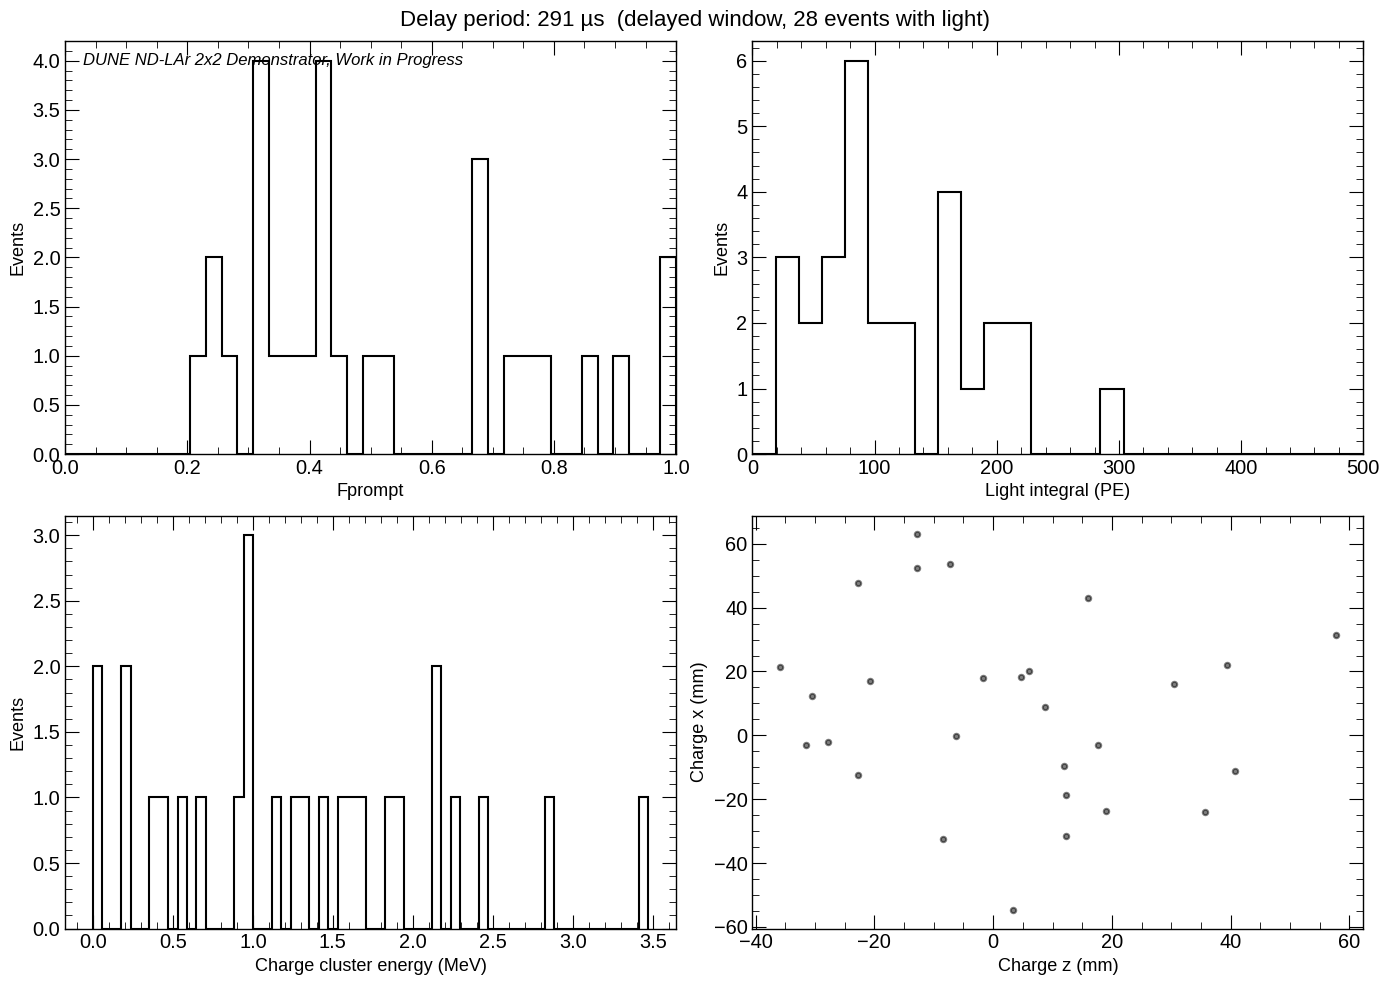

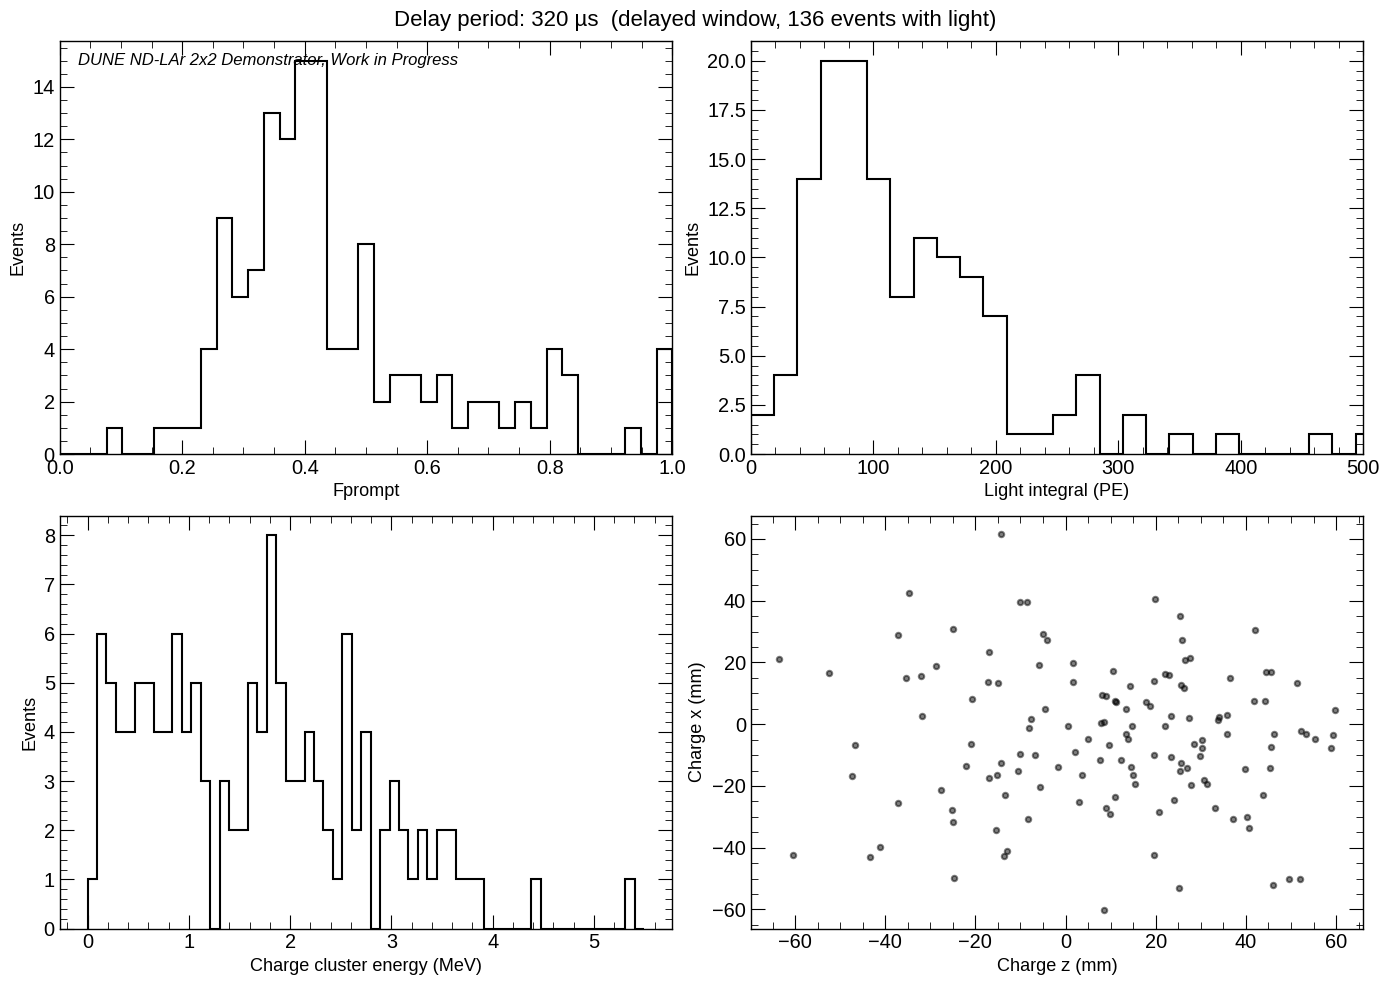

In [52]:
# ── Per-period detail loop ────────────────────────────────────────────────────
for period in PERIODS:
    sub = events_all[(events_all["period"] == period) & (events_all["window"] == "delayed")]
    plot_period_detail(sub, period)

## 2D fprompt vs light integral (all prompt windows)

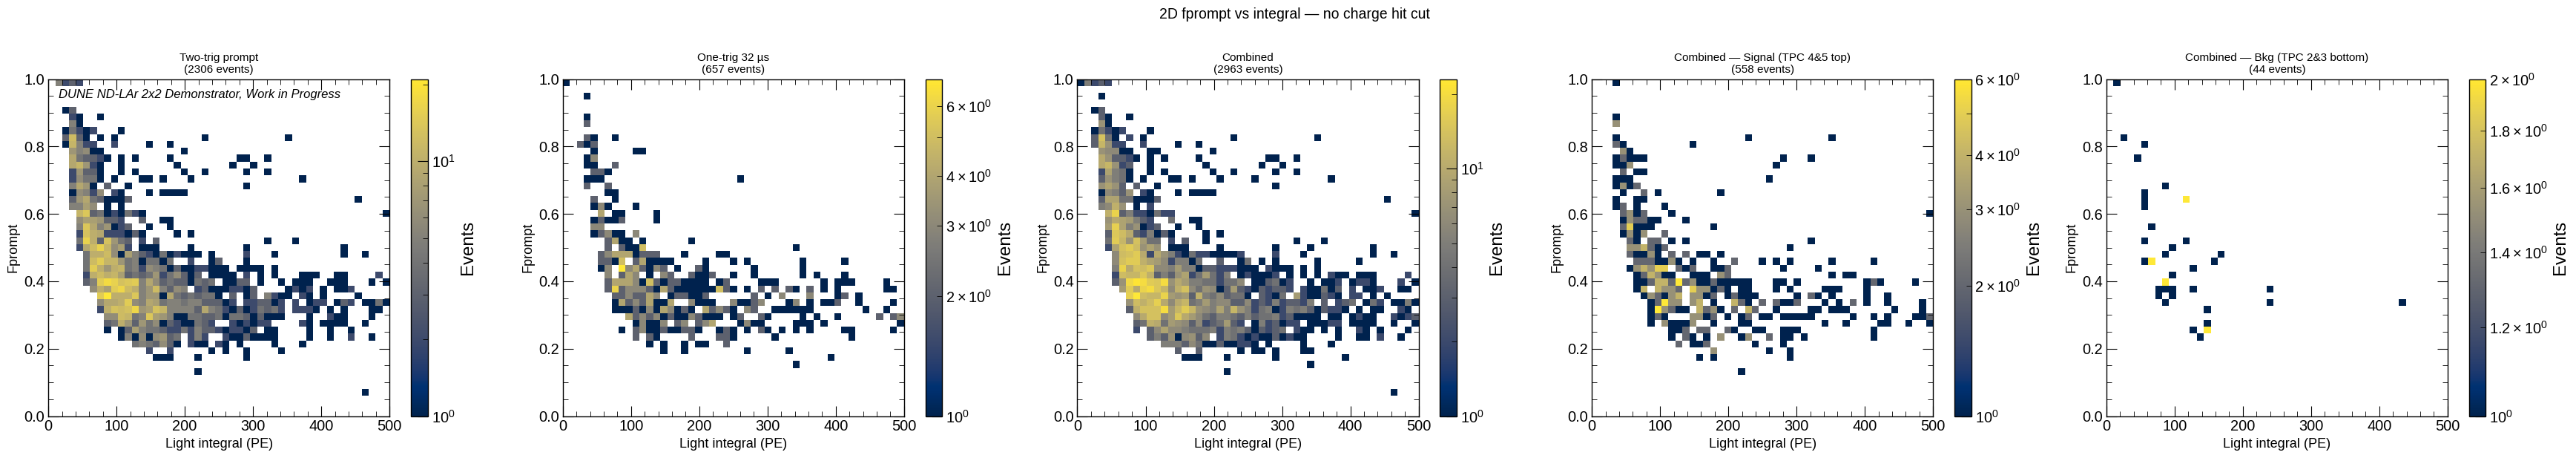

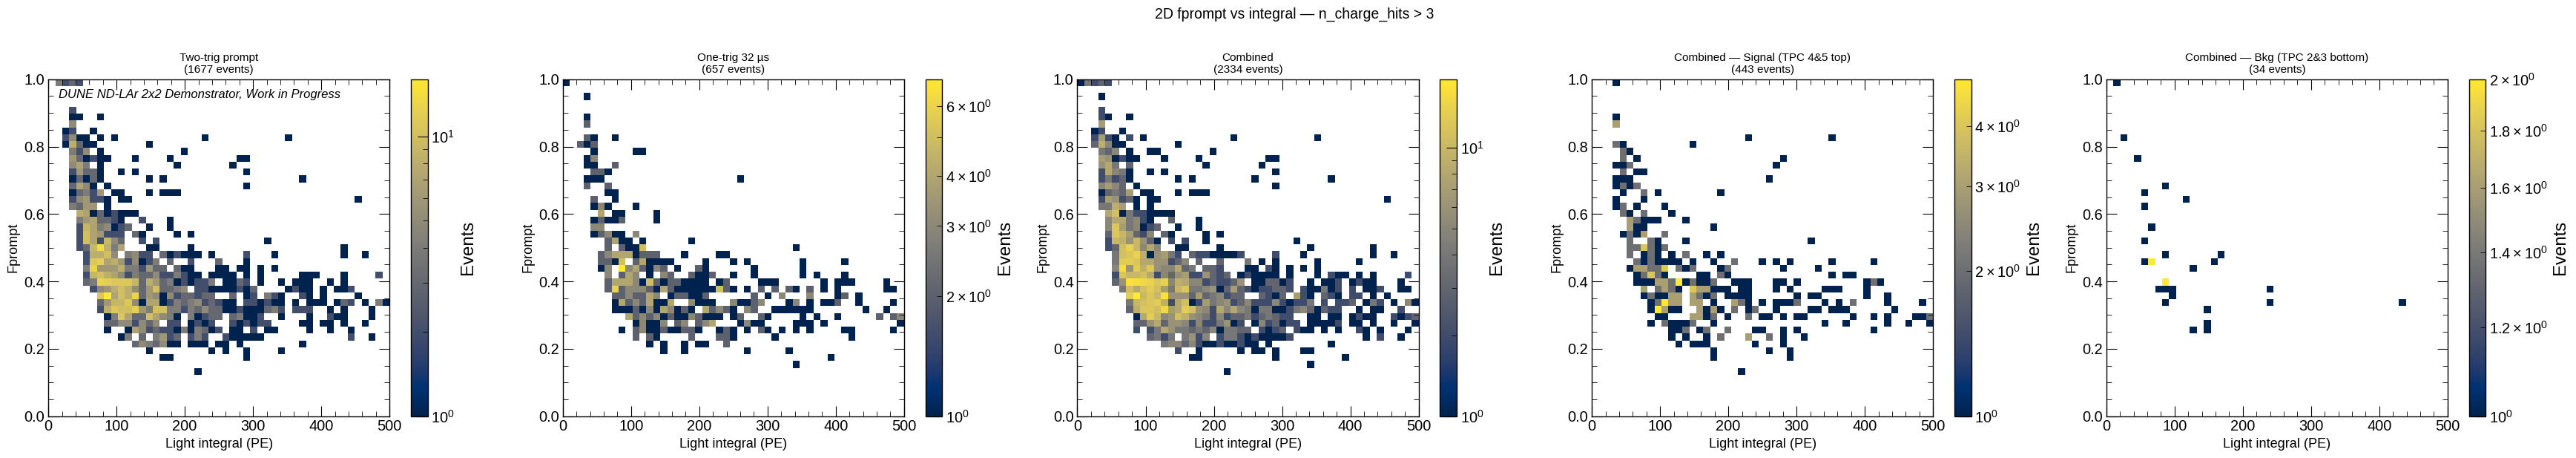

In [77]:
# ── 2D fprompt vs light integral: signal vs background, per cut ───────────────
bins_x = np.linspace(0, 500, 50)
bins_y = np.linspace(0, 1, 50)

for cut in CHARGE_HIT_CUTS:
    two_trig, one_trig, combined = get_prompt_subsets(events_all, cut)
    cut_label = f"n_charge_hits > {cut}" if cut > 0 else "no charge hit cut"
    cut_tag = f"cut{cut}"

    # TPC-based signal/background from source data
    sig_mask = (combined["tpc"].isin([4, 5])) & (combined["position"] == "top")
    bkg_mask = (combined["tpc"].isin([2, 3])) & (combined["position"] == "bottom")

    panels = [
        ("Two-trig prompt", two_trig),
        ("One-trig 32 µs", one_trig),
        ("Combined", combined),
        ("Combined — Signal (TPC 4&5 top)", combined[sig_mask]),
        ("Combined — Bkg (TPC 2&3 bottom)", combined[bkg_mask]),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 6))
    for ax, (title, df) in zip(axes, panels):
        if len(df) > 0:
            h = ax.hist2d(df["integral"], df["fprompt"],
                          bins=[bins_x, bins_y], cmap="cividis", norm=LogNorm(), cmin=1)
            fig.colorbar(h[3], ax=ax, label="Events")
        ax.set_xlabel("Light integral (PE)", fontsize=13)
        ax.set_ylabel("Fprompt", fontsize=13)
        ax.set_title(f"{title}\n({len(df)} events)", fontsize=11)
        ax.tick_params(direction="in")

    dune_label(axes[0], **get_dune_kwargs("2d", cut))
    fig.suptitle(f"2D fprompt vs integral — {cut_label}", fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURE_DIR, f"2d_fprompt_integral_{cut_tag}.png"), dpi=350, bbox_inches="tight")
    plt.show()

## Interactive spatial investigation from 2D fprompt-integral regions

Define box cuts in (integral, fprompt) space below to see the spatial distribution of charge clusters in each region. Edit the `regions` dict to explore different populations.

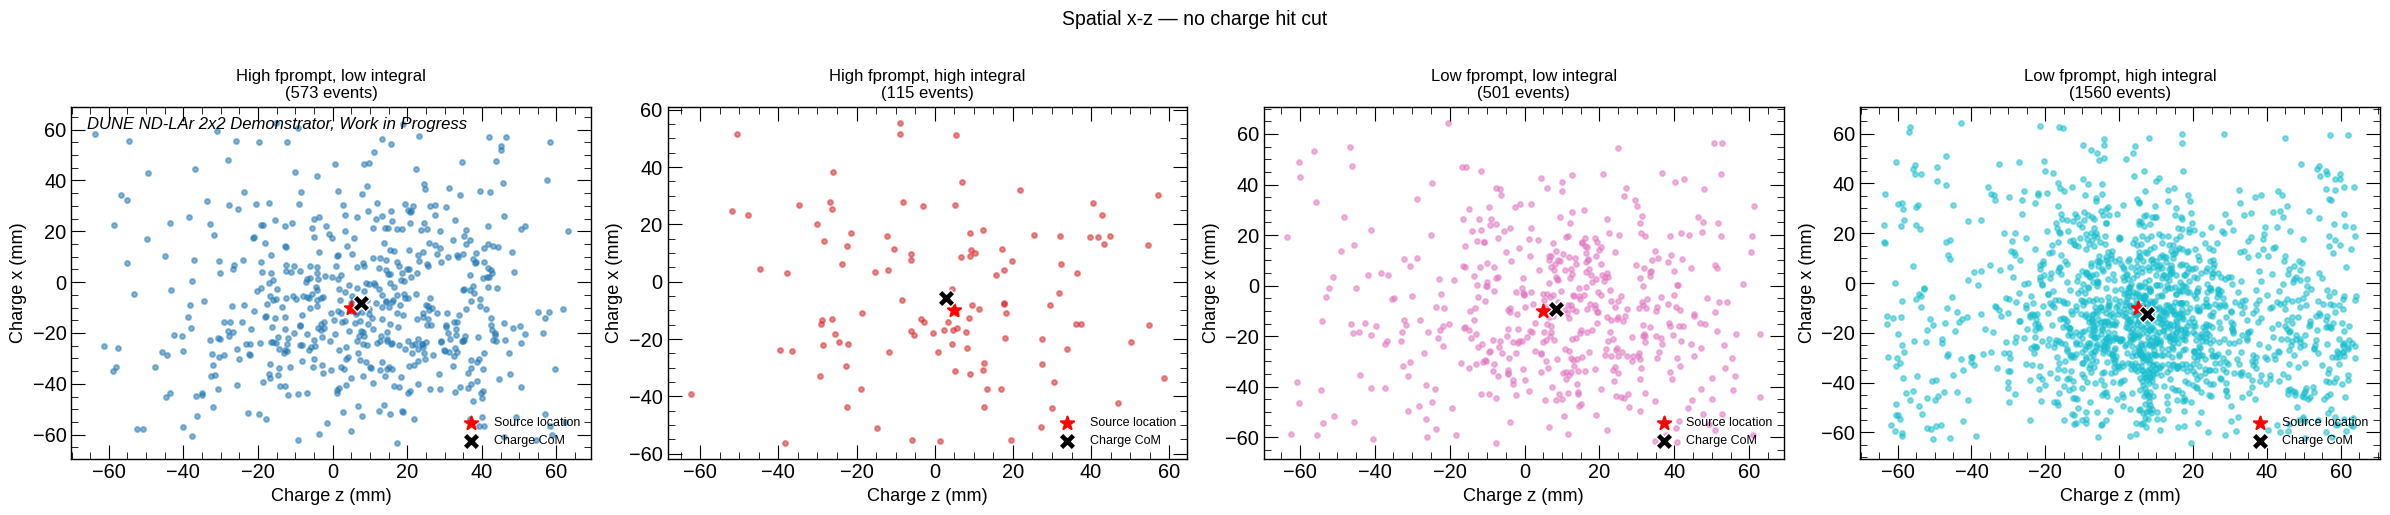

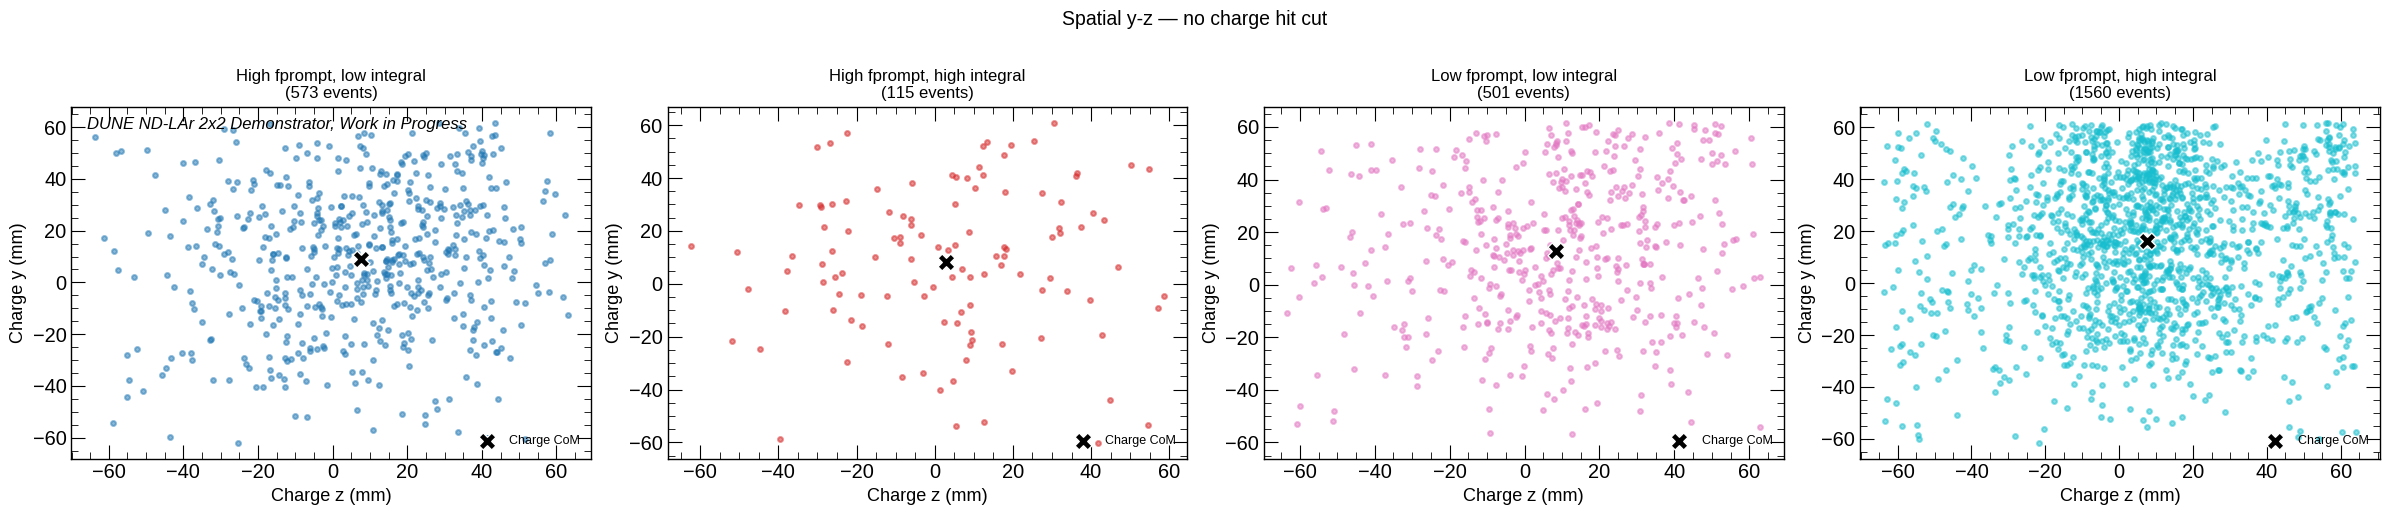

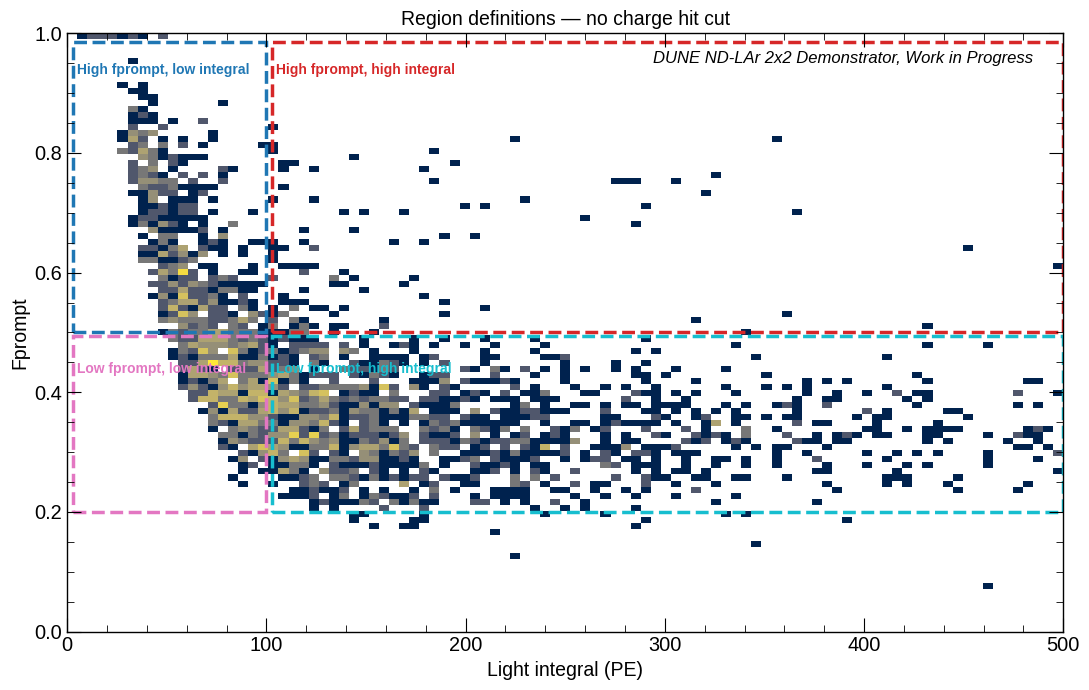

In [78]:
# ── Define regions in (integral, fprompt) space to investigate spatially ───────
# Edit these to explore different populations!
# Format: "label": (integral_min, integral_max, fprompt_min, fprompt_max)

regions = {
    "High fprompt, low integral":  (0,   100,  0.5, 1.0),
    "High fprompt, high integral": (100,  500, 0.5, 1.0),
    "Low fprompt, low integral":   (0,   100,  0.2, 0.5),
    "Low fprompt, high integral":  (100,  500, 0.2, 0.5),
}

SPATIAL_CUT = 0  # which charge hit cut to use for spatial investigation

_, _, data_to_probe = get_prompt_subsets(events_all, SPATIAL_CUT)
cut_label = f"n_charge_hits > {SPATIAL_CUT}" if SPATIAL_CUT > 0 else "no charge hit cut"

n_regions = len(regions)
colors = plt.cm.tab10(np.linspace(0, 1, n_regions))

# x-z view
fig, axes = plt.subplots(1, n_regions, figsize=(6 * n_regions, 5))
if n_regions == 1:
    axes = [axes]
for ax, (label, (int_lo, int_hi, fp_lo, fp_hi)), color in zip(axes, regions.items(), colors):
    sel = data_to_probe[
        (data_to_probe["integral"] >= int_lo) & (data_to_probe["integral"] < int_hi) &
        (data_to_probe["fprompt"] >= fp_lo) & (data_to_probe["fprompt"] < fp_hi)
    ]
    ax.scatter(sel["charge_z"], sel["charge_x"], s=12, alpha=0.5, color=color)
    ax.scatter(x=5, y=-10, marker="*", s=100, color="red", zorder=5, label="Source location")
    if len(sel) > 0:
        ax.scatter(sel["charge_z"].mean(), sel["charge_x"].mean(),
                   marker="X", s=150, color="black", edgecolors="white",
                   linewidths=1, zorder=10, label="Charge CoM")
    ax.legend(fontsize=9, loc="lower right")
    ax.set_xlabel("Charge z (mm)", fontsize=13)
    ax.set_ylabel("Charge x (mm)", fontsize=13)
    ax.set_title(f"{label}\n({len(sel)} events)", fontsize=12)
    ax.tick_params(direction="in")
dune_label(axes[0])
fig.suptitle(f"Spatial x-z — {cut_label}", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "spatial_xz_regions.png"), dpi=350, bbox_inches="tight")
plt.show()

# y-z view
fig, axes = plt.subplots(1, n_regions, figsize=(6 * n_regions, 5))
if n_regions == 1:
    axes = [axes]
for ax, (label, (int_lo, int_hi, fp_lo, fp_hi)), color in zip(axes, regions.items(), colors):
    sel = data_to_probe[
        (data_to_probe["integral"] >= int_lo) & (data_to_probe["integral"] < int_hi) &
        (data_to_probe["fprompt"] >= fp_lo) & (data_to_probe["fprompt"] < fp_hi)
    ]
    ax.scatter(sel["charge_z"], sel["charge_y"], s=12, alpha=0.5, color=color)
    if len(sel) > 0:
        ax.scatter(sel["charge_z"].mean(), sel["charge_y"].mean(),
                   marker="X", s=150, color="black", edgecolors="white",
                   linewidths=1, zorder=10, label="Charge CoM")
    ax.legend(fontsize=9, loc="lower right")
    ax.set_xlabel("Charge z (mm)", fontsize=13)
    ax.set_ylabel("Charge y (mm)", fontsize=13)
    ax.set_title(f"{label}\n({len(sel)} events)", fontsize=12)
    ax.tick_params(direction="in")
dune_label(axes[0])
fig.suptitle(f"Spatial y-z — {cut_label}", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "spatial_yz_regions.png"), dpi=350, bbox_inches="tight")
plt.show()

# Region overlay on 2D plot
fig, ax = plt.subplots(figsize=(11, 7))
ax.hist2d(
    data_to_probe["integral"], data_to_probe["fprompt"],
    bins=[np.linspace(0, 500, 100), np.linspace(0, 1, 100)],
    cmap="cividis", norm=LogNorm(), cmin=1,
)
for (label, (int_lo, int_hi, fp_lo, fp_hi)), color in zip(regions.items(), colors):
    rect = plt.Rectangle((int_lo + 3, fp_lo), int_hi - int_lo - 3, fp_hi - 1.03 * fp_lo,
                          edgecolor=color, facecolor="none", linewidth=2.5, linestyle="--")
    ax.add_patch(rect)
    ax.text(int_lo + 5, fp_hi - 0.05, label, fontsize=10, color=color, fontweight="bold",
            va="top")
ax.set_xlabel("Light integral (PE)", fontsize=14)
ax.set_ylabel("Fprompt", fontsize=14)
ax.set_title(f"Region definitions — {cut_label}", fontsize=14)
ax.tick_params(direction="in")
dune_label(ax, loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "spatial_region_definitions.png"), dpi=350, bbox_inches="tight")
plt.show()